# Table of Contents

- [Dataset analysis](#dataset-analysis)
  - [Feature Overview](#feature-overview)
  - [Statistical Summary](#statistical-summary)
  - [Data Types](#data-types)
  - [Dataset Insights and Feature Types](#dataset-insights-and-feature-types)
- [Data Treatment](#data-treatment)
  - [Missing Values](#missing-values)
  - [Alert missing values imputation strategy](#alert-missing-values-imputation-strategy)
    - [Location missing values imputation strategy](#location-missing-values-imputation-strategy)
    - [Country missing values imputation strategy](#country-missing-values-imputation-strategy)
    - [Continent missing values imputation strategy](#continent-missing-values-imputation-strategy)
  - [Missing data findings and resaolutions](#missing-data-findings-and-resaolutions)
  - [Encoding Categorical Features and Text Features](#encoding-categorical-features-and-text-features)
  - [Further data visualization and issue identification](#further-data-visualization-and-issue-identification)
  - [Scaling our features](#scaling-our-features)
    - [Data Splitting](#data-splitting)
  - [Feature Reduction, analysis and selection](#feature-reduction-analysis-and-selection)
    - [Feature engineering](#feature-engineering)
    - [Feature Importance Ranking (SHAP and GINI combined) along with Domain Relevance](#feature-importance-ranking-shap-and-gini-combined-along-with-domain-relevance)
  - [An imbalnced dataset](#an-imbalnced-dataset)
    - [Dataset imbalance handling techniques discussion](#dataset-imbalance-handling-techniques-discussion)
- [Data limitation and quality issues](#data-limitation-and-quality-issues)
- [Ethics and Privacy Considerations](#ethics-and-privacy-considerations)
- [Model Selection Rationale](#model-selection-rationale)
  - [Model 1: Logistic Regression with Class Weights](#model-1-logistic-regression-with-class-weights)
  - [Model 2: Gradient Boosting classifier](#model-2-gradient-boosting-classifier)
- [Research questions](#research-questions)
- [Model Training](#model-training)
  - [Model 1: Logistic Regression](#model-1-logistic-regression)
    - [Hyperparameter Tuning for Logistic Regression](#hyperparameter-tuning-for-logistic-regression)
    - [Exploring C (regularization strength)](#exploring-c-regularization-strength)
    - [Further Hyperparameter Tuning for general performance improvement (max iterations and tolerance)](#further-hyperparameter-tuning-for-general-performance-improvement-max-iterations-and-tolerance)
    - [Class weight tuning](#class-weight-tuning)
    - [Grid Search for Hyperparameter Optimization](#grid-search-for-hyperparameter-optimization)
  - [Model 2: Gradient Boosting Classifier](#model-2-gradient-boosting-classifier)
    - [Hyperparameter Tuning for Gradient Boosting Classifier](#hyperparameter-tuning-for-gradient-boosting-classifier)
    - [Tree depth and number of estimators tuning](#tree-depth-and-number-of-estimators-tuning)
    - [Grid Search for Hyperparameter Optimization](#grid-search-for-hyperparameter-optimization)
- [Results and Evaluation](#results-and-evaluation)
  - [Training, Validation, and Test Performance comparison](#training-validation-and-test-performance-comparison)
  - [Precision, Recall, and F1-Score comparison](#precision-recall-and-f1-score-comparison)
  - [ROC and AUC performance comparison](#roc-and-auc-performance-comparison)
  - [Confusion Matrix Analysis](#confusion-matrix-analysis)
  - [Statistical Significance Testing](#statistical-significance-testing)
  - [Model comparison summary](#model-comparison-summary)
  - [Research questions](#research-questions)
  - [Limitations and Future Work](#limitations-and-future-work)
- [Reflection](#reflection)
- [References](#references)
- [Appendix](#appendix)
  - [AI Usage Disclosure](#ai-usage-disclosure)

https://www.kaggle.com/datasets/warcoder/earthquake-dataset?select=earthquake_1995-2023.csv


In [1698]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

## Dataset analysis

This dataset was compiled by Chirag Chauhan and uploaded to Kaggle. It contains data on 782 significant earthquakes worldwide from 2001 to 2022. The dataset contains various features related to earthquakes. The data origninates from the United States Geological Survey (USGS) earthquake everywhere API. There are various real world applications for this dataset, including earthquake analysis, tsunami risk prediction, and seismic hazard assessment. (Chauhan, 2024)


My objective is to build a model that utilises this dataset to predict the occurrence of tsunamis following earthquakes based on the characteristics of the seismic events, something this dataset is well suited for given its selection of features. This has been something of interest for the seismology community, the topic area the dataset belongs to for sometime, with various studies having been conducted on the relationship between earthquake characteristics and tsunami generation (Lomax, Michelini and Piatanesi, 2011).


### Feature Overview

| Column       | Description                                                                                                                                            |
|--------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| title        | Name given to earthquake                                                                                                                     |
| magnitude    | Magnitude of earthquake                                                                                                                        |
| date_time    | Date and time                                                                                                                                          |
| cdi          | Maximum reported intensity for event range                                                                                                   |
| mmi          | Maximum estimated instrumental intensity for  event                                                                                             |
| alert        | Alert level, “green”, “yellow”, “orange”, and “red”                                                                                                |
| tsunami      | "1" for events in oceanic regions and "0" otherwise                                                                                                     |
| sig          | Number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined by magnitude, maximum MMI, felt reports, and estimated impact |
| net          | ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.                               |
| nst          | Total number of seismic stations used to determine earthquake location.                                                                            |
| dmin         | Horizontal distance from the epicenter to the nearest station                                                                                          |
| gap          | Largest azimuthal gap between azimuthally adjacent stations (in degrees). Smaller numbers indicate more reliable positions. Gaps >180° have large uncertainties |
| magType      | Method or algorithm used to calculate the preferred magnitude for the event                                                                       |
| depth        | Depth where the earthquake begins to rupture                                                                                                        |
| latitude     | Latitude coordinate of the earthquake                                                                                                                  |
| longitude    | Longitude coordinate of the earthquake                                                                                                                 |
| location     | Location within the country                                                                                                                            |
| continent    | Continent of the earthquake-hit country                                                                                                                |
| country      | Affected country                                                                                                                                       |

(figure 1)

(Chauhan, 2024)

In [1699]:
df = pd.read_csv('data/earthquake_data.csv')

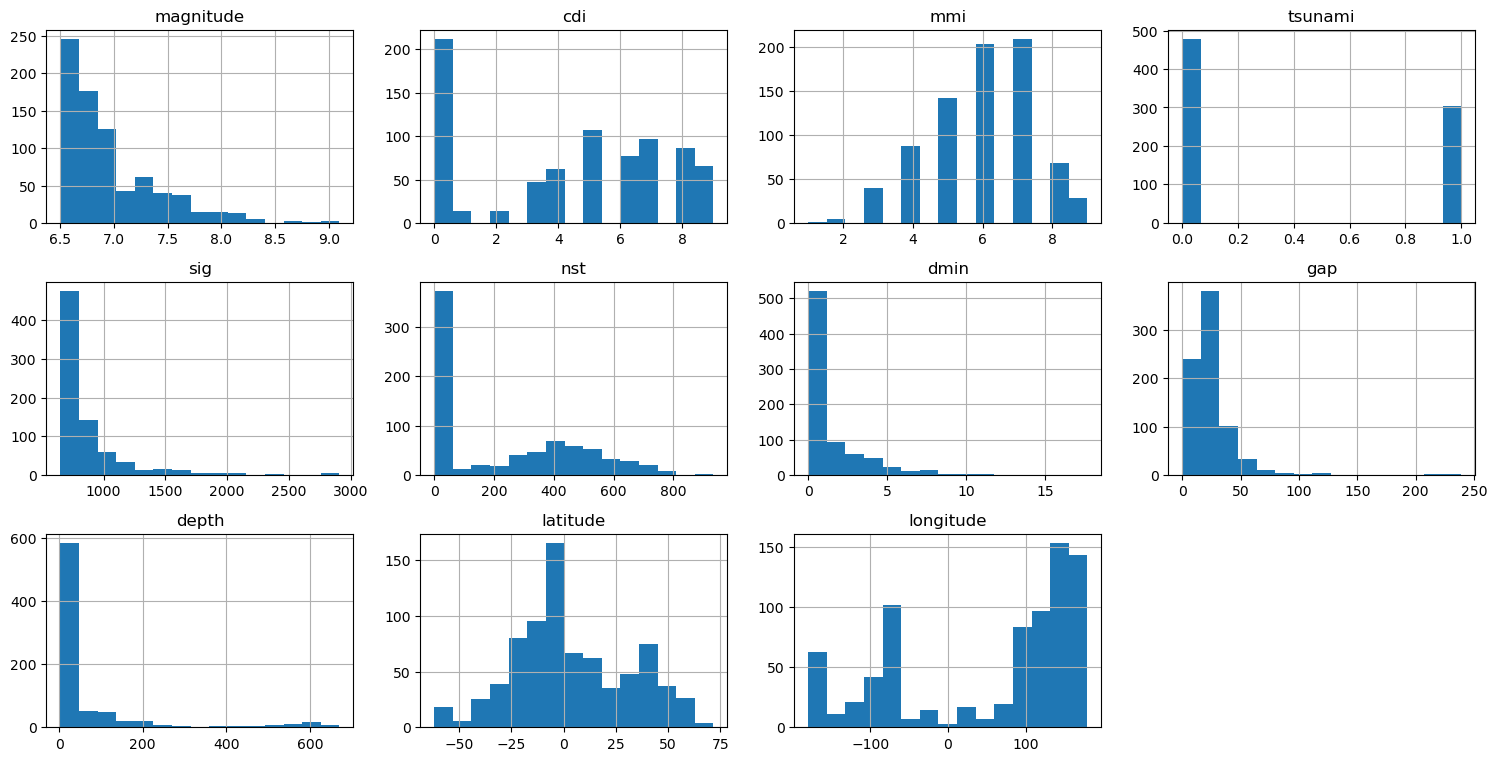

In [1700]:
df.hist(bins=15, figsize=(15,10), layout=(4,4))
plt.tight_layout()
plt.show()

Figure 2: Histograms of Numerical Features

In [1701]:
df.sample(16)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
605,"M 6.6 - 99 km SSE of Panguna, Papua New Guinea",6.6,01-04-2007 20:47,0,7,NaN,0,670,us,251,0.000,16.0,mb,10.00,-7.1690,155.7770,"Panguna, Papua New Guinea",NaN,Solomon Islands
201,"M 7.7 - Komandorskiye Ostrova, Russia region",7.7,17-07-2017 23:34,8,7,green,1,918,us,0,3.564,13.0,mww,10.00,54.4434,168.8570,"Komandorskiye Ostrova, Russia region",NaN,NaN
705,"M 6.6 - 51 km NW of Isangel, Vanuatu",6.6,06-11-2003 10:38,0,5,NaN,0,670,us,475,0.000,26.2,mwb,113.70,-19.2620,168.8920,"Isangel, Vanuatu",NaN,NaN
582,"M 6.8 - 30 km E of Macas, Ecuador",6.8,16-11-2007 03:13,7,6,NaN,0,790,us,649,0.000,27.0,mwc,122.90,-2.3120,-77.8380,"Macas, Ecuador",South America,Ecuador
318,"M 6.6 - 115 km W of Panguna, Papua New Guinea",6.6,07-12-2014 01:22,1,5,green,1,670,us,0,3.246,12.0,mww,23.00,-6.5108,154.4600,"Panguna, Papua New Guinea",NaN,NaN
375,"M 6.5 - Kermadec Islands, New Zealand",6.5,30-09-2013 05:55,0,4,green,1,650,us,0,1.709,21.0,mww,41.54,-30.9255,-178.3230,"Kermadec Islands, New Zealand",NaN,NaN
341,"M 6.5 - 110 km SE of Punta de Burica, Panama",6.5,13-05-2014 06:35,7,5,green,1,694,us,0,3.121,33.0,mww,10.00,7.2096,-82.3045,"Punta de Burica, Panama",NaN,NaN
329,M 6.9 - Federated States of Micronesia region,6.9,03-08-2014 00:22,0,4,green,1,732,us,0,6.393,12.0,mww,13.00,0.8295,146.1690,Micronesia region,NaN,NaN
716,"M 6.5 - 41 km N of Rabaul, Papua New Guinea",6.5,15-07-2003 18:46,0,6,NaN,0,650,us,156,0.000,31.4,mwb,33.00,-3.8280,152.1740,"Rabaul, Papua New Guinea",NaN,Papua New Guinea
187,"M 7.0 - 85 km ENE of Tadine, New Caledonia",7.0,19-11-2017 22:43,4,6,green,1,771,us,0,0.617,14.0,mww,10.00,-21.3246,168.6710,"Tadine, New Caledonia",NaN,NaN


### Statistical Summary


In [1702]:
df.describe()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,0.388747,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199
std,0.445514,3.169939,1.462724,0.487778,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886
min,6.500000,0.000000,1.000000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000
25%,6.600000,0.000000,5.000000,0.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050
50%,6.800000,5.000000,6.000000,0.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000
75%,7.100000,7.000000,7.000000,1.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000
max,9.100000,9.000000,9.000000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000


In [1703]:
print(f'Dataset Shape: {df.shape}')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print('Column Names:', df.columns.tolist())

Dataset Shape: (782, 19)
Rows: 782, Columns: 19
Column Names: ['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude', 'location', 'continent', 'country']


### Data Types


In [1704]:
unique_values = df.nunique()
print(f'Unique values per column:\n{unique_values}')
country_unique_variables_before_imputation = df['country'].nunique()

Unique values per column:
title        768
magnitude     24
date_time    773
cdi           10
mmi            9
alert          4
tsunami        2
sig          339
net           11
nst          312
dmin         369
gap          256
magType        9
depth        303
latitude     778
longitude    777
location     413
continent      6
country       49
dtype: int64


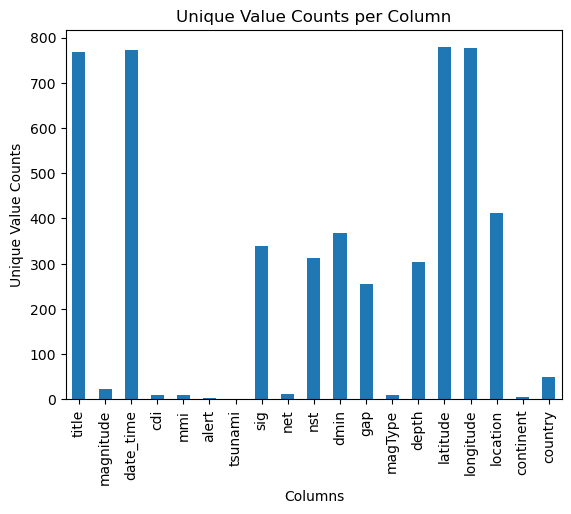

In [1705]:
df.nunique(axis=0).plot(kind='bar')
plt.title('Unique Value Counts per Column')
plt.xlabel('Columns')
plt.ylabel('Unique Value Counts')
plt.show()

Figure 3: This chart displays the number of unique values in each dataset column, helping distinguish categorical features (with fewer unique values) from numerical features (with many).

In [1706]:
print(df.dtypes)

title         object
magnitude    float64
date_time     object
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
net           object
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
location      object
continent     object
country       object
dtype: object


### Dataset Insights and Feature Types

To understand the dataset, a statistical summary and data type audit was conducted. These revealed that many numerical variables, particularly those related to earthquake magnitude and impact, exhibit strong left skewed distributions (see Figures 1 and 2). This indicates that most recorded earthquakes are low magnitude, low impact events, with relatively few high magnitude observations. Such imbalance may bias models toward predicting lower impact earthquakes.

Figure 3 and the data-type overview show that the dataset contains both numerical and categorical features, requiring tailored preprocessing. According to the USGS, `mmi` and `cdi` are discrete intensity scales, whereas `magnitude` represents a continuous measure of energy release; therefore, `magnitude` will be treated as numerical and cdi/mmi as ordered categorical variables (United States Geological Survey, no date; Wald et al., 2011; United States Geological Survey, 1989). `title` and `location` are unstructured text features due to their object types and high uniqueness, while `date_time` is a datetime variable.

The target variable, `tsunami`, is a binary numerical feature with two values (0 and 1), indicating whether a tsunami followed the earthquake. As noted in Chauhan (2024), this makes it well aligned with the with the goal of predicting tsunami occurrence via binary classification models.

| Types of data               | Features                                               |
|-----------------------------|--------------------------------------------------------|
| Numerical Features          | `magnitude`, `sig`, `nst`, `dmin`, `gap`, `depth`, `latitude`, `longitude` |
| Categorical Numerical Features        | `cdi`, `mmi`                                          |
| Datetime Feature            | `date_time`                                           |
| Categorical Text Feature   | `alert`, `net`, `magType`, `continent`, `country`          |
| Unstructured Text Feature   | `title`, `location`                                   |
| Target Variable (Binary Numerical) | `tsunami`                                             |

Figure 4: Data Types of Features and Target Variable

## Data Treatment

### Missing Values

In [1707]:
print(df.isnull().sum())

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


In [1708]:
place_holders = [-9999, 9999, np.inf, -np.inf, 'nan', 'NaN', 'NA', 'null', 'NULL', '']
print(df.isin(place_holders).sum().sum() + df.isnull().sum().sum())

1246


In [1709]:
#percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
print(f'Percentage of missing values per column:\n{missing_percentage}')

Percentage of missing values per column:
alert        46.930946
location      0.639386
continent    73.657289
country      38.107417
dtype: float64


In [1710]:
missing_values_datatypes = df[missing_percentage.index].dtypes
print(f'Data types of columns with missing values:\n{missing_values_datatypes}')

Data types of columns with missing values:
alert        object
location     object
continent    object
country      object
dtype: object


In [1711]:
df[missing_percentage.index].sample(16)

,alert,location,continent,country
253,green,"Ashk?sham, Afghanistan",Asia,Afghanistan
393,green,Okhotsk,NaN,NaN
105,green,"Severo-Kuril’sk, Russia",NaN,NaN
75,green,"Kermadec Islands, New Zealand",NaN,NaN
531,NaN,"Sola, Vanuatu",NaN,NaN
203,yellow,"Lim-oo, Philippines",NaN,Philippines
580,NaN,"Dompu, Indonesia",NaN,Indonesia
591,NaN,"Sungai Penuh, Indonesia",NaN,Indonesia
535,NaN,"Matavai, Samoa",NaN,NaN
256,green,"Port-Olry, Vanuatu",NaN,Vanuatu


| **Feature**              | **Type of Missingness**           | **Reason / Explanation**                                                                                                                                                                                                                 |
|---------------------------|----------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Alert Level**           | Missing Not At Random (MNAR)     | Missingness is related to the unobserved value itself, less significant earthquakes are less likely to have an alert level assigned.                                                              |
| **Location**              | Missing At Random (MAR)          | Missingness depends on other observed variables (latitude and longitude). Location may not be recorded because coordinates are already available.                                                  |
| **Country**               | Missing At Random (MAR)          | Missingness is related to latitude and longitude data, the country may be inferred from coordinates, making direct recording unnecessary.                                                         |
| **Continent**             | Missing At Random (MAR)          | Missingness depends on other observed information (such as latitude, longitude, or country) and is not directly related to the continent value itself.                                              |



Figure 10: Missingness Types for Features with Missing Data

### Alert missing values imputation strategy

<Axes: xlabel='alert'>

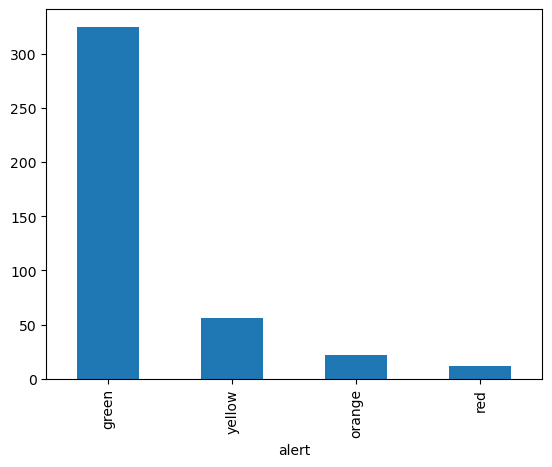

In [1712]:
df['alert'].value_counts().plot(kind='bar')

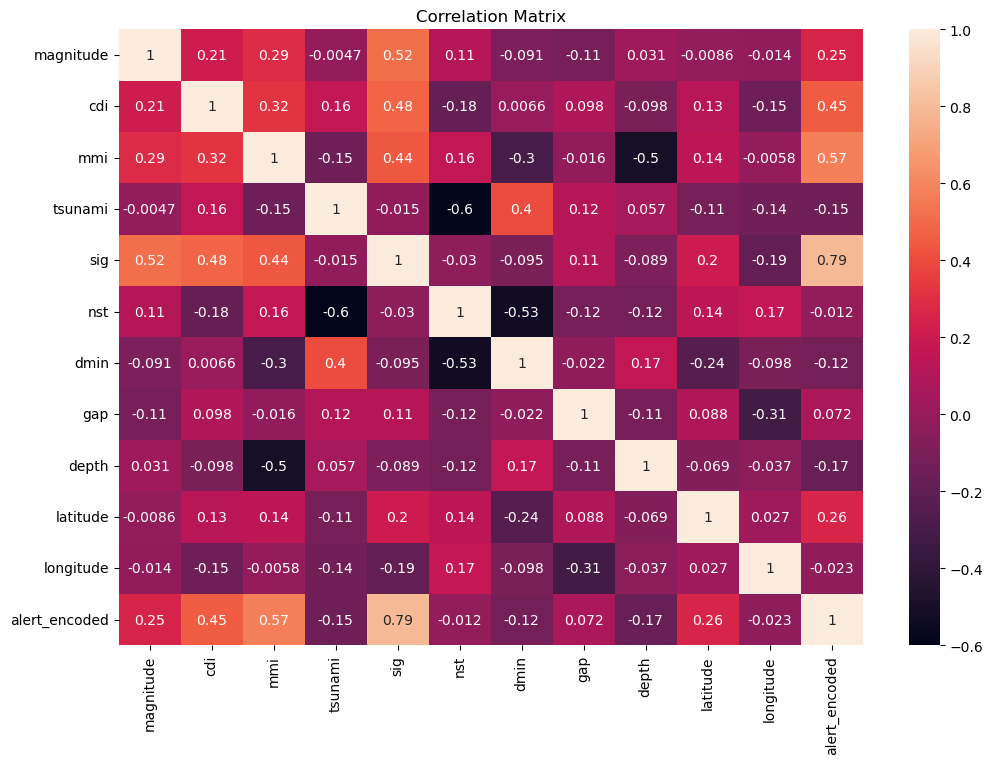

In [1713]:
alert_order = {'green': 1, 'yellow': 2, 'orange': 3, 'red': 4}
df_temp = df.copy()
df_temp['alert_encoded'] = df_temp['alert'].map(alert_order)
numerical_cols = df_temp.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_temp[numerical_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

Figure 6: Correlation between Numerical Features and Encoded Alert Levels

In [1714]:
print(df.groupby('alert').agg({
    'sig': ['mean']
}).sig)

               mean
alert              
green    773.224615
orange  1382.136364
red     2475.000000
yellow  1047.696429


In [1715]:
alert_thresholds = df.groupby('alert').agg({
    'sig': ['mean']
}).sig

green_threshold = alert_thresholds.loc['green', 'mean'] #index by alert level, get column 'mean'
yellow_threshold = alert_thresholds.loc['yellow', 'mean']
orange_threshold = alert_thresholds.loc['orange', 'mean']
red_threshold = alert_thresholds.loc['red', 'mean']

#Order of alert levels: red, orange, yellow, green - source: (United States Geological Survey, 2010)

def impute_alert(row):
    if pd.isnull(row['alert']):
        if row['sig'] >= red_threshold:
            return 'red'
        elif row['sig'] >= orange_threshold:
            return 'orange'
        elif row['sig'] >= yellow_threshold:
            return 'yellow'
        else:
            return 'green'
    else:
        return row['alert']
df['alert'] = df.apply(impute_alert, axis=1)
print(f'Missing values in alert column after imputation: {df["alert"].isnull().sum()}')

Missing values in alert column after imputation: 0


#### Location missing values imputation strategy

<Axes: >

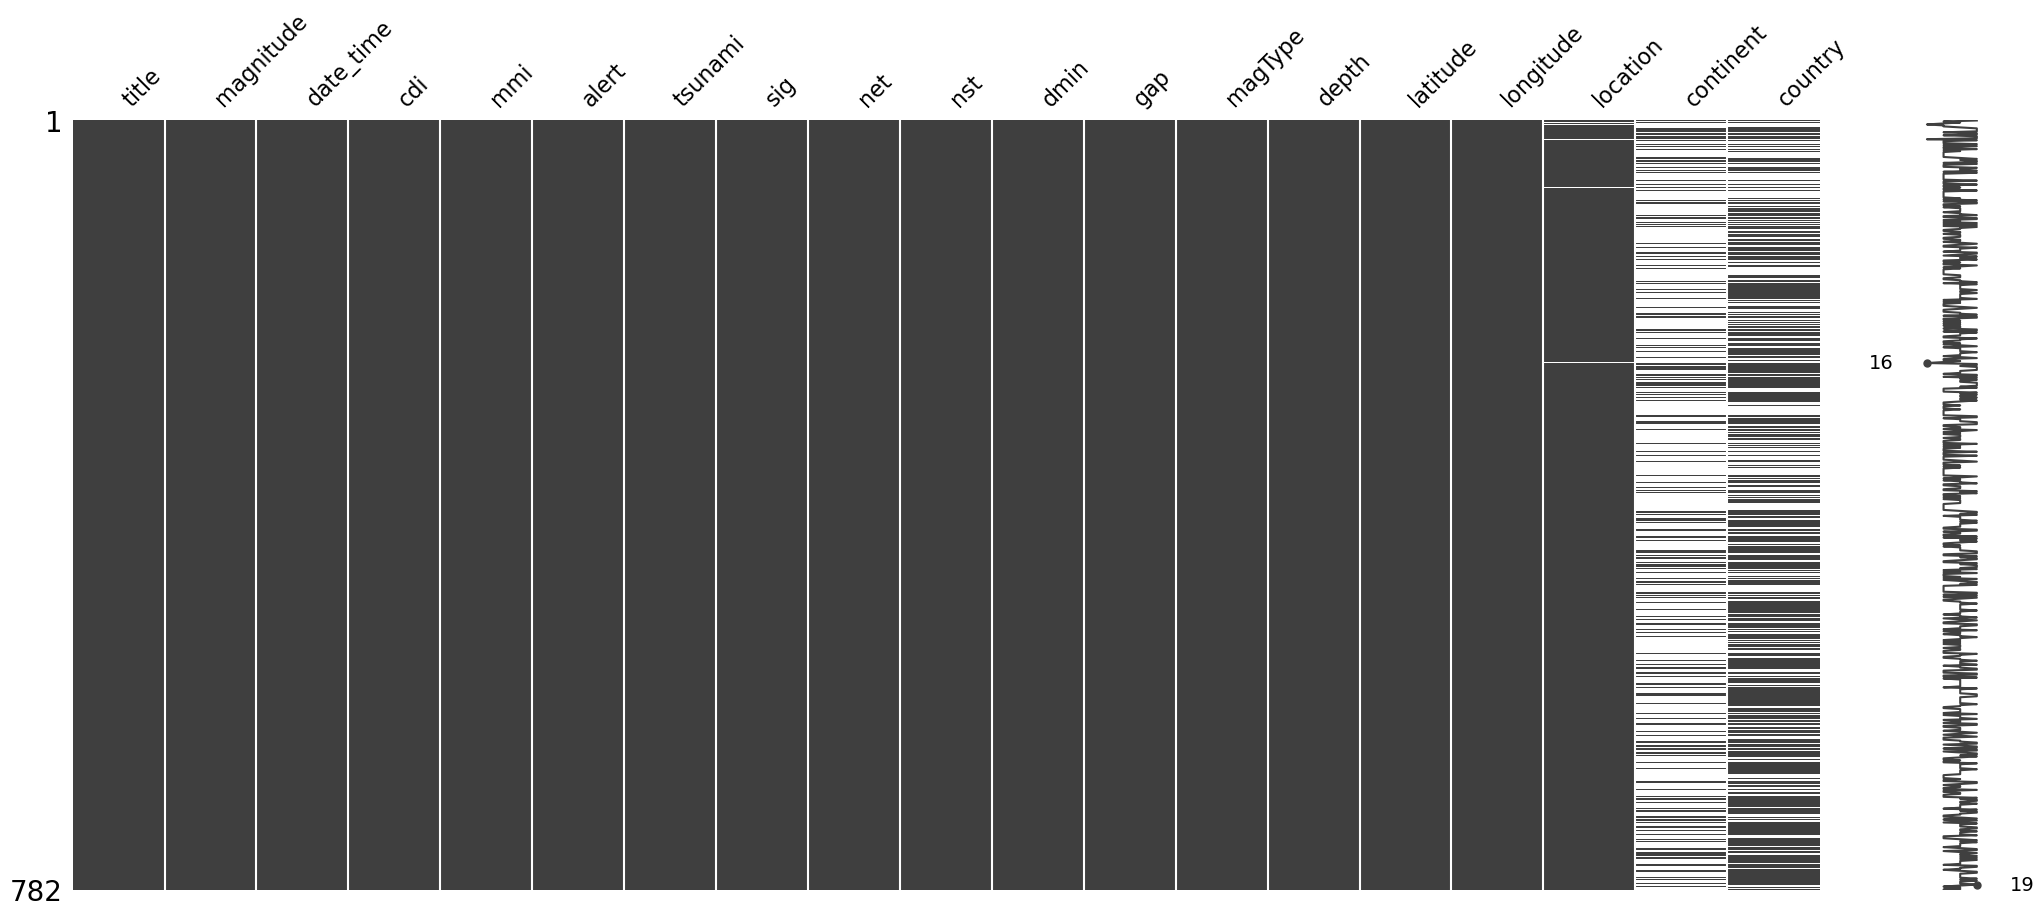

In [1716]:
msno.matrix(df)

Figure 7: Missingness Pattern for All Features

In [1717]:
print(f'Missing values in location column before imputation: {df["location"].isnull().sum()}')
def impute_location(row):
    if pd.isnull(row['location']):
        if not pd.isnull(row['country']):
            return f'{row["country"]}'
        else:
            return np.nan # cannot impute location
    else:
        return row['location']
df['location'] = df.apply(impute_location, axis=1)
print(f'Missing values in location column after imputation: {df["location"].isnull().sum()}')

Missing values in location column before imputation: 5
Missing values in location column after imputation: 3


In [1718]:
df = df.dropna(subset=['location'])
print('Data shape after dropping rows with missing location:', df.shape)

Data shape after dropping rows with missing location: (779, 19)


The remaining missing values in the location column are those where both location and country were missing so we could not impute anything meaningful.

In [1719]:
print(df.location.sample(15))

471               Tachilek, Myanmar
379                    Atka, Alaska
222           Lospalos, Timor Leste
321               Tobelo, Indonesia
549            Manokwari, Indonesia
772              Ternate, Indonesia
738         Punta de Burica, Panama
649              Singkil, Indonesia
176         Kimbe, Papua New Guinea
610              Ternate, Indonesia
744                   Nuxco, Mexico
94     Popondetta, Papua New Guinea
66              Sinabang, Indonesia
96       Santa María Xadani, Mexico
112                   Neiafu, Tonga
Name: location, dtype: object


#### Country missing values imputation strategy

In [1720]:
coma_count = df['location'].str.contains(',').sum()
print(f'Percentage of locations with a comma: {(coma_count / len(df)) * 100:.2f}%')

Percentage of locations with a comma: 91.40%


Figure 18: Many location entries include an area–country format (e.g., "Los Angeles, USA"), enabling missing country values to be inferred.

In [1721]:
print(f'Missing values in country column before imputation: {df["country"].isnull().sum()}')
def impute_country(row):
    if pd.isnull(row['country']):
        if ',' in row['location']:
            return row['location'].split(',')[-1].strip() # extract country from location using the last part after comma
        else:
            return np.nan # cannot impute country
    else:
        return row['country']

df['country'] = df.apply(impute_country, axis=1)
print(f'Missing values in country column after imputation: {df["country"].isnull().sum()}')

Missing values in country column before imputation: 295
Missing values in country column after imputation: 42


In [1722]:
missing_country_locations = df[df['country'].isnull()]['location']
print(f'Locations with missing country values:\n{missing_country_locations}')

Locations with missing country values:
5                            the Fiji Islands
6                            the Fiji Islands
15                       the Kermadec Islands
22                        the Loyalty Islands
28                           the Fiji Islands
30                    Kermadec Islands region
45                             Vanuatu region
46                             Vanuatu region
52              South Sandwich Islands region
56              South Sandwich Islands region
57              South Sandwich Islands region
67                 Mauritius - Reunion region
73                    Kermadec Islands region
78                        the Loyalty Islands
85                 central Mid-Atlantic Ridge
88                 central Mid-Atlantic Ridge
97                       the Kermadec Islands
137              Prince Edward Islands region
160                          the Fiji Islands
161                   Kermadec Islands region
186                      Bouvet Island re

Many of the 42 samples lacking country data correspond to small islands, territories, ocean regions, or disputed areas.

In [1723]:
df['country'] = df['country'].fillna(df['location'])
print(f'Missing values in country column after final imputation: {df["country"].isnull().sum()}')

Missing values in country column after final imputation: 0


#### Continent missing values imputation strategy

<Axes: >

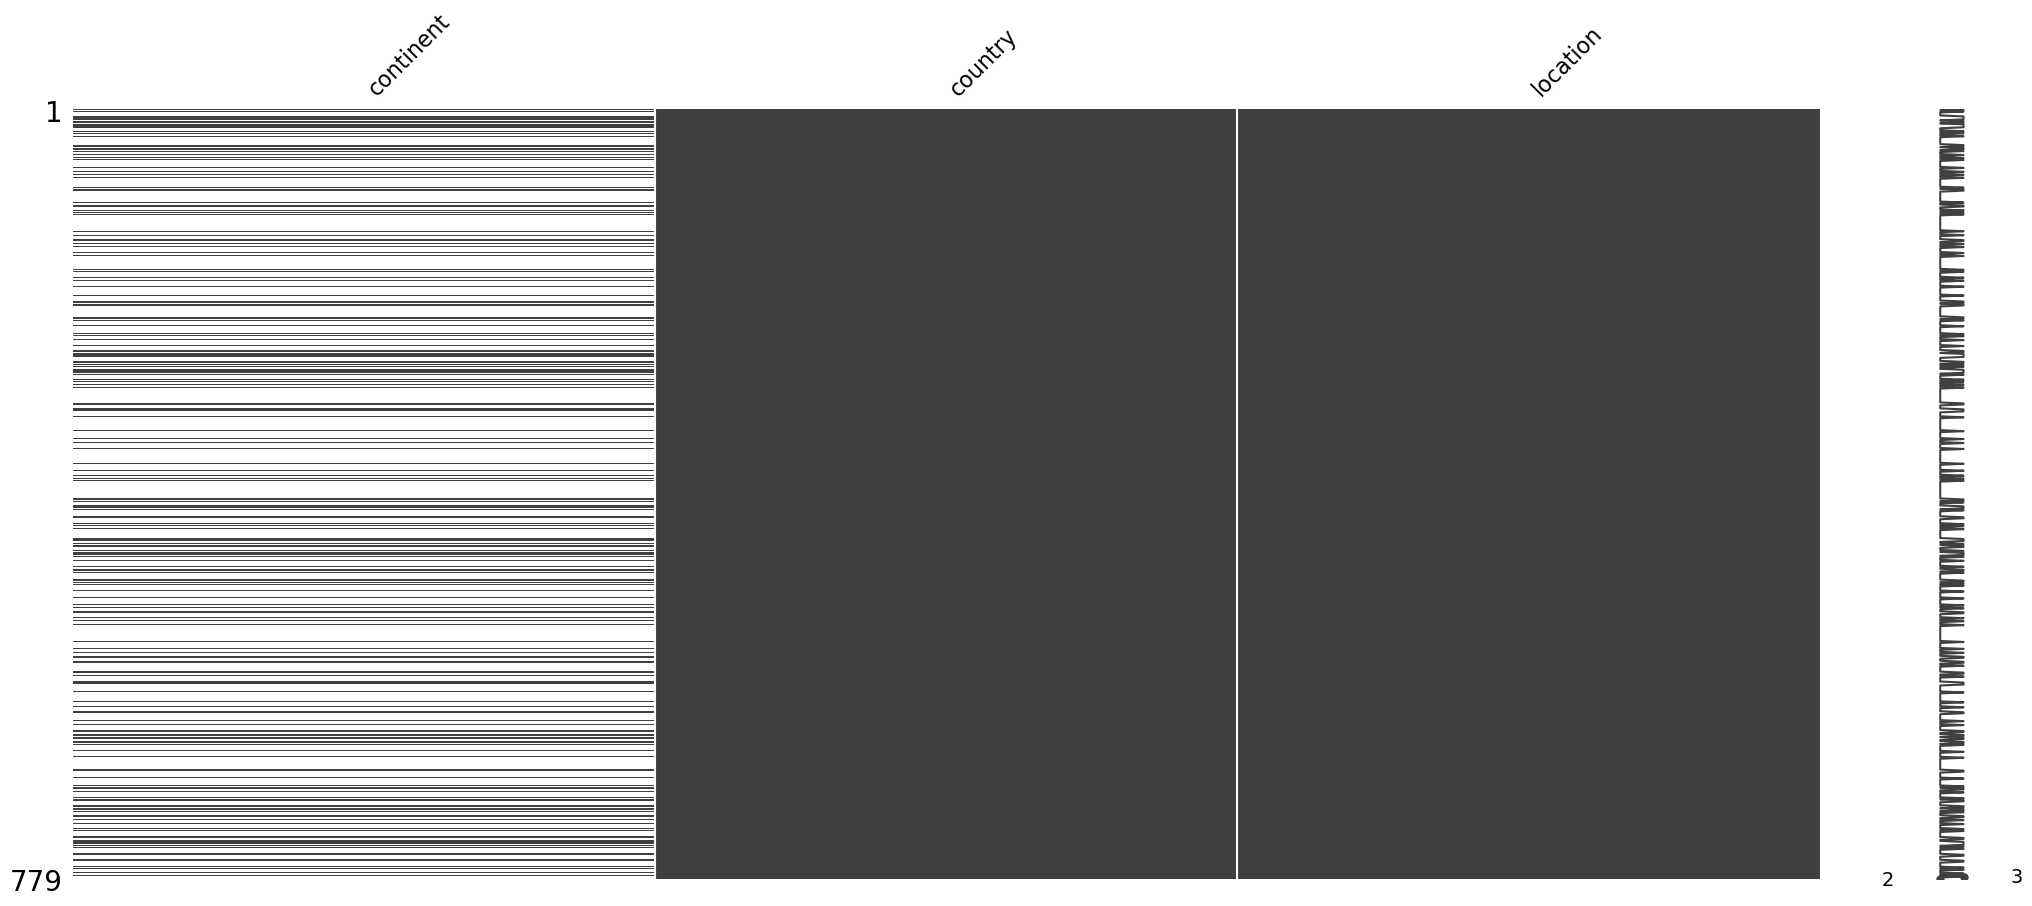

In [1724]:
msno.matrix(df[['continent', 'country', 'location']])

In [1725]:
df = df.drop(columns=['continent'])
print(df.columns)

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'country'],
      dtype='object')


In [1726]:
total_missing_after = df.isnull().sum().sum()
print(f'Total missing values after imputation: {total_missing_after}')

Total missing values after imputation: 0


In [1727]:
X, y = df.drop(columns='tsunami'), df['tsunami']
X.shape, y.shape, X.columns

((779, 17),
 (779,),
 Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'sig', 'net',
        'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude',
        'location', 'country'],
       dtype='object'))

### Missing data findings and resaolutions

We initially examined missing data patterns using both percentage based calculations and visualizations (Figure 7), identifying the extent and type of missingness across features (Figure 10). Imputation strategies were tailored accordingly: rule based imputation was applied to `alert` based on its correlation with `sig` (figure 6), while inter feature relationships guided imputation for `location` and `country`. The `continent` feature was dropped due to excessive missingness. These approaches aimed to preserve data integrity and minimize imputation bias.

### Encoding Categorical Features and Text Features

In [1728]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_features = ['alert']
ordinal_encoder = OrdinalEncoder(categories=[['green', 'yellow', 'orange', 'red']])
X[ordinal_features] = ordinal_encoder.fit_transform(X[ordinal_features])

We must also encode our remaining categorical text features: `net`, `magType`, and `country` (figure 3). These are nominal categorical variables as there is no inherent order to the categories they represent (figure 1). We will use one-hot encoding to convert these nominal categorical features into numerical format by creating binary indicator variables for each category.

In [1729]:
#one-hot encoding of nominal categorical features
columns_before = X.shape[1]
nominal_features = ['net', 'magType']
X = pd.get_dummies(X, columns=nominal_features, drop_first=True)
columns_after = X.shape[1]

49
87


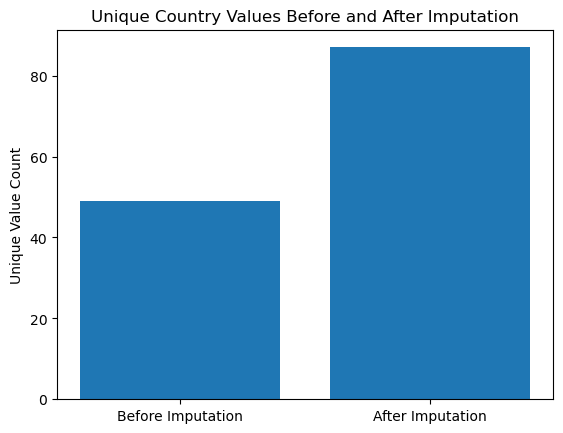

In [1730]:
print(country_unique_variables_before_imputation)
print(df.country.nunique())
plt.bar(['Before Imputation', 'After Imputation'], [country_unique_variables_before_imputation, df.country.nunique()])
plt.title('Unique Country Values Before and After Imputation')
plt.ylabel('Unique Value Count')
plt.show()

In [1731]:
X[['country', 'location']].sample(16)

,country,location
262,Indonesia,"Sarangani, Philippines"
166,Peru,"Iñapari, Peru"
430,El Salvador,"Puerto El Triunfo, El Salvador"
43,Japan,"Hirara, Japan"
39,People's Republic of China,"northern Qinghai, China"
278,Afghanistan,"Hindu Kush region, Afghanistan"
263,India,"Imph?l, India"
426,Indonesia,"Tual, Indonesia"
176,Papua New Guinea,"Kimbe, Papua New Guinea"
259,United States of America,"Pedro Bay, Alaska"


figure 9: Location and Country content sample

In [1732]:
X = X.drop(columns=['country'])

Now we must process our unstructured text features: `title` and `location` (figure 4). These features contain freeform text data that cannot be directly used in most ML models so we will need to convert this text data into numerical format using text vectorization techniques. Given the similarity of content between `Country` and with `Location` features (figure 9 & 18), we will only keep the `location` feature to avoid redundancy and increasing dimensionality yet further.

In [ ]:
import gensim.downloader as api
word2vec_model = api.load('glove-wiki-gigaword-50') #pre-trained Word2Vec model with 50-dimensional vectors

def average_word_vectors(text, model): #Averaging vectors Inspired by (itdxer, 2017)
    words = str(text).lower().split()
    vectors = []
    for word in words:
        if word in model: #When you iterate through model, you get the words in the vocabulary (it must have a custom __iter__ method)
            vectors.append(model[word])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

title_vectors = X['title'].apply(lambda x: average_word_vectors(x, word2vec_model))
location_vectors = X['location'].apply(lambda x: average_word_vectors(x, word2vec_model))
title_df = pd.DataFrame(title_vectors.tolist(), index=X.index).add_prefix('title_vec_') #takes index from original X to align rows
location_df = pd.DataFrame(location_vectors.tolist(), index=X.index).add_prefix('location_vec_')
X = pd.concat([X, title_df, location_df], axis=1)
X = X.drop(columns=['title', 'location'])
X

In [ ]:
object_columns = X.select_dtypes(include=['object']).columns.tolist()
print(f'Object type columns in X: {object_columns}')

Object type columns in X: ['date_time']


In [ ]:
X['time'] = pd.to_datetime(X['date_time'])
X['time'] = pd.to_datetime(X['time']).astype(int)/ 10**9 #unix timestamp - (AlwaysSunny, 2019)
X = X.drop(columns=['date_time'])

/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_89080/1096151919.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X['time'] = pd.to_datetime(X['date_time'])


In [ ]:
object_columns = X.select_dtypes(include=['object']).columns.tolist()
print(f'Object type columns in X: {object_columns}')
datatime_columns = X.select_dtypes(include=['datetime64[ns]']).columns.tolist()
print(f'Datetime type columns in X: {datatime_columns}')

Object type columns in X: []
Datetime type columns in X: []


### Further data visualization and issue identification

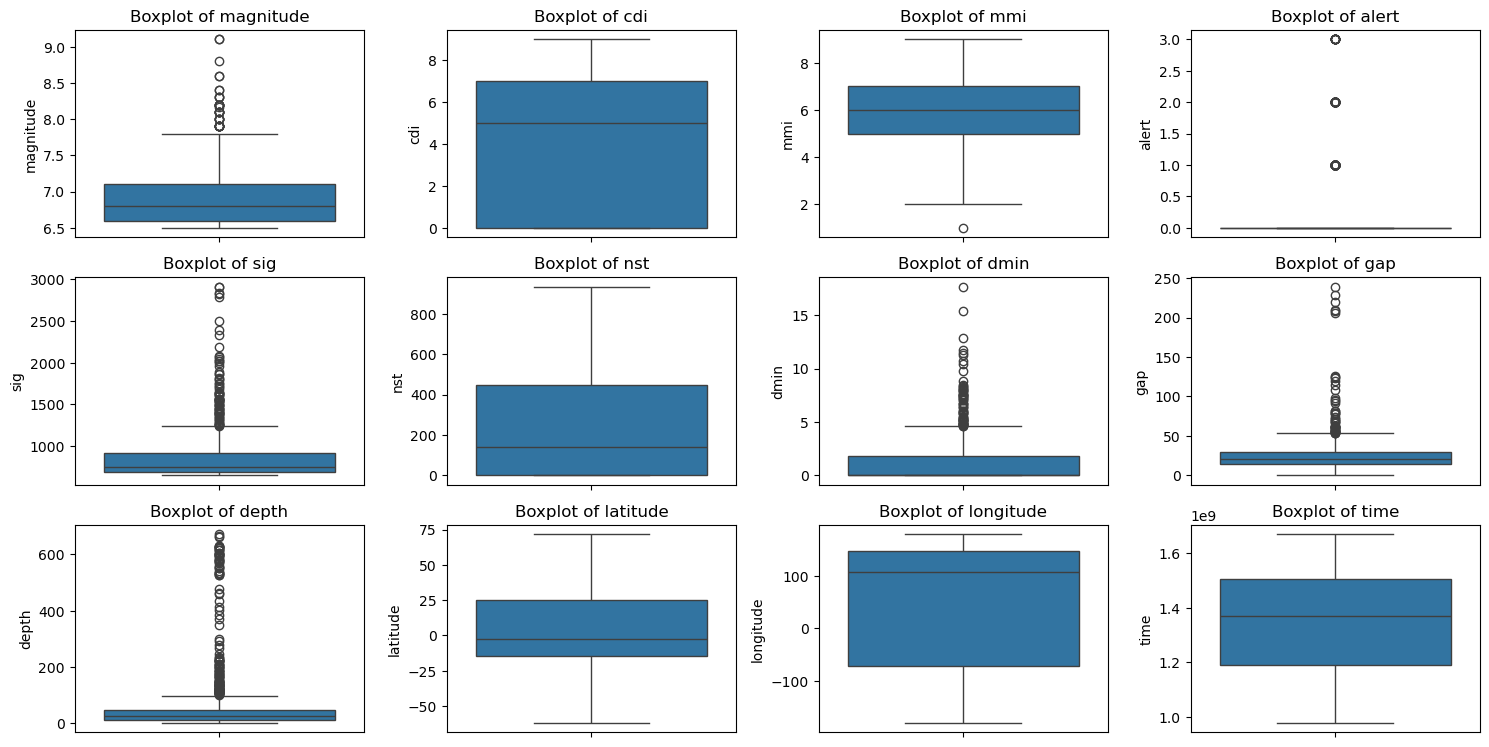

In [ ]:
non_encoded_render = [c for c in X.columns if '_' not in c] #exclude vectorized text features for boxplots because they have many dimensions
plt.figure(figsize=(15,10))
for i, col in enumerate(non_encoded_render):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=X[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

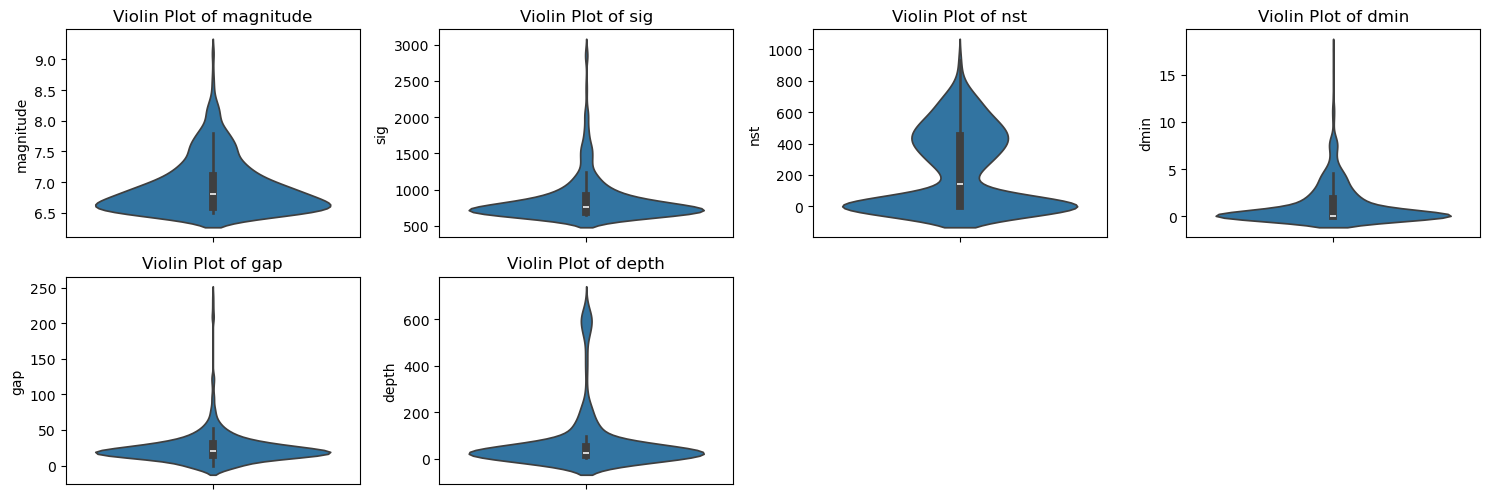

In [ ]:
features_of_interest = ['magnitude', 'sig', 'nst', 'dmin', 'gap', 'depth']
plt.figure(figsize=(15,10))
for i, col in enumerate(features_of_interest):
    plt.subplot(4, 4, i + 1)
    sns.violinplot(y=X[col])
    plt.title(f'Violin Plot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
for col in features_of_interest:
    min_value = X[col].min()
    print(f'Minimum value in {col}: {min_value}')

Minimum value in magnitude: 6.5
Minimum value in sig: 650
Minimum value in nst: 0
Minimum value in dmin: 0.0
Minimum value in gap: 0.0
Minimum value in depth: 2.7


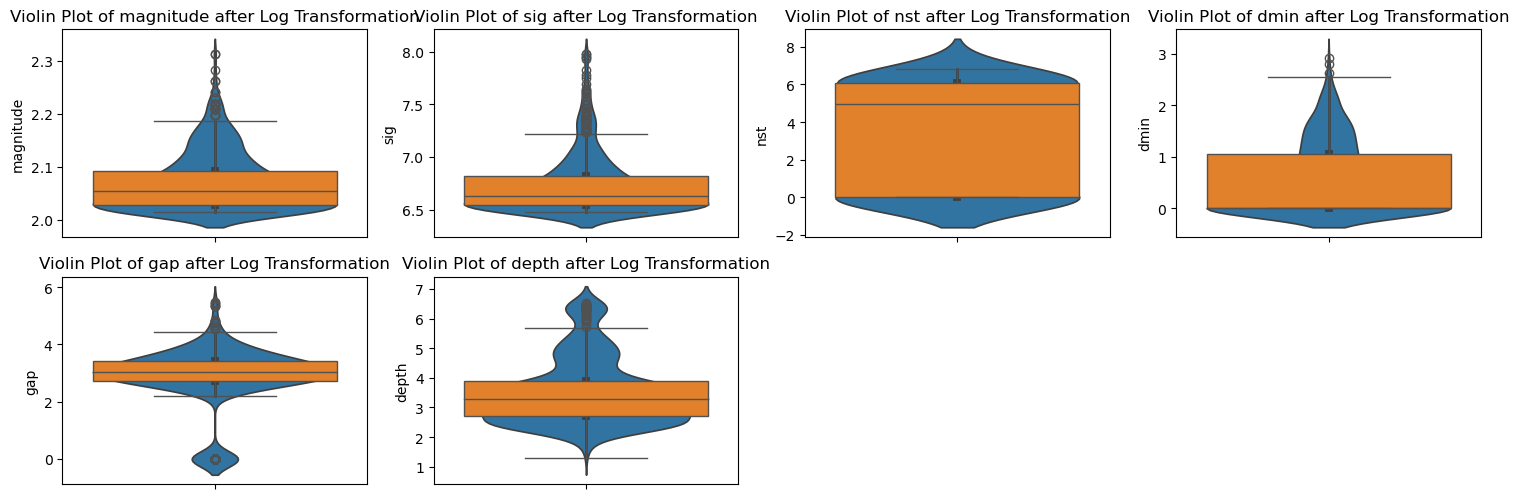

In [ ]:
X[features_of_interest] = X[features_of_interest].apply(lambda x: np.log1p(x)) #(ChatGPT, 2025)
plt.figure(figsize=(15,10))
for i, col in enumerate(features_of_interest):
    plt.subplot(4, 4, i + 1)
    sns.violinplot(y=X[col])
    sns.boxplot(y=X[col])
    plt.title(f'Violin Plot of {col} after Log Transformation')
plt.tight_layout()
plt.show()

In [ ]:
print(X.isnull().sum().sum())

0


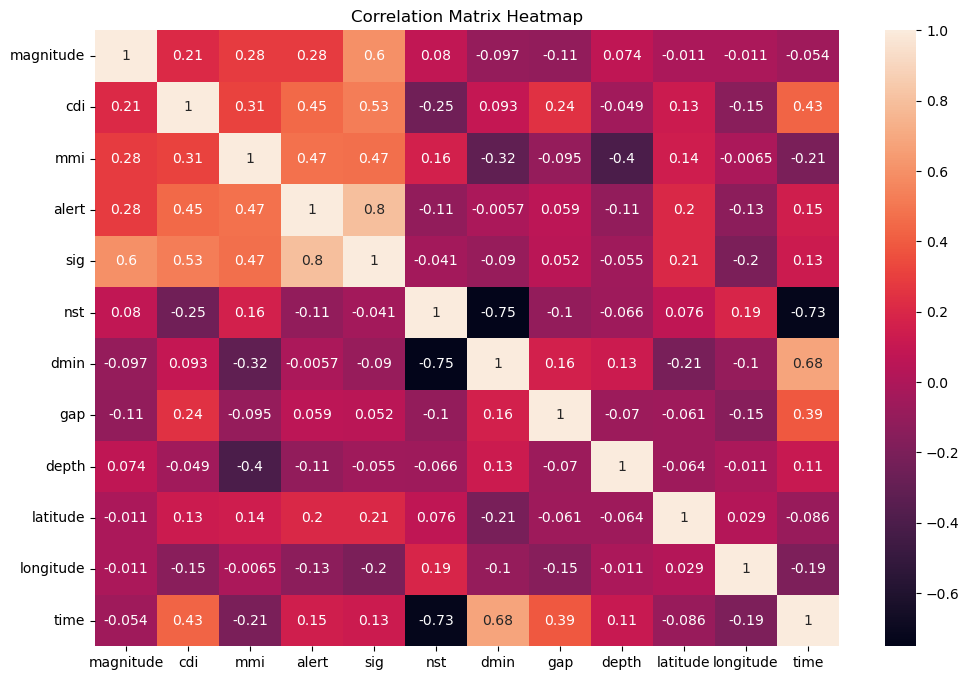

In [ ]:
corr_matrix = X[non_encoded_render].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
duplicate_rows = X.duplicated().sum()
print(f'Number of duplicate rows in X: {duplicate_rows}')

Number of duplicate rows in X: 0


### Scaling our features

The scaling of features is a critical part of data preprocessing in ML. It involves transforming the features to a common scale without distorting differences in the ranges of values. Without scaling, larger features will receive disproportionate weight updates during training if using gradient descent based algorithms, leading to unstable model training and convergence issues.

#### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split, LearningCurveDisplay

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #This is z-score normalization
scaler = scaler.fit(X_train)

In [ ]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=X.columns, index=y_train.index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=y_test.index)

### Feature Reduction, analysis and selection

In [ ]:
df[['country', 'location','title']].sample(16)

,country,location,title
387,Papua New Guinea,"Kandrian, Papua New Guinea","M 6.6 - 26 km NE of Kandrian, Papua New Guinea"
287,Solomon Islands,"Gizo, Solomon Islands","M 6.5 - 177 km SE of Gizo, Solomon Islands"
581,Papua New Guinea,"Lae, Papua New Guinea","M 6.8 - 107 km N of Lae, Papua New Guinea"
665,Japan,"Katsuura, Japan","M 6.6 - 161 km SE of Katsuura, Japan"
382,Alaska,"Atka, Alaska","M 7.0 - 101 km SW of Atka, Alaska"
153,Canada,"Port McNeill, Canada","M 6.5 - 223 km SW of Port McNeill, Canada"
580,Indonesia,"Dompu, Indonesia","M 6.5 - 28 km NNW of Dompu, Indonesia"
397,People's Republic of China,"Linqiong, China","M 6.6 - 56 km WSW of Linqiong, China"
552,Kyrgyzstan,"Nookat, Kyrgyzstan","M 6.7 - 131 km SE of Nookat, Kyrgyzstan"
714,New Zealand,"Te Anau, New Zealand","M 7.2 - 56 km NW of Te Anau, New Zealand"


In [ ]:
X_train = X_train.loc[:, ~X_train.columns.str.startswith('title_')]
X_test = X_test.loc[:, ~X_test.columns.str.startswith('title_')]
X_train

,magnitude,cdi,mmi,alert,sig,nst,dmin,gap,depth,latitude,...,location_vec_41,location_vec_42,location_vec_43,location_vec_44,location_vec_45,location_vec_46,location_vec_47,location_vec_48,location_vec_49,time
684,-0.781268,-1.393092,-1.354430,-0.426307,-0.774581,1.016230,-0.789202,0.518093,-1.018347,1.088711,...,-2.429809,1.016017,-0.561602,2.078923,-0.506003,0.778634,1.736585,-0.193437,0.542834,-1.378351
336,2.126487,0.512278,1.374138,-0.426307,0.508931,-1.040467,-0.611232,0.225103,1.097526,1.758870,...,1.220799,-1.558831,2.129505,-0.200849,-1.899784,2.937766,-0.810882,-0.497027,1.790587,0.251936
28,-0.302934,-0.757968,-2.036572,-0.426307,-0.559510,-1.040467,1.938696,-0.347335,2.552764,-0.959846,...,0.217713,-0.579541,1.447976,-0.940839,-0.022829,-0.609472,-0.680410,0.168777,-0.527258,1.525840
725,1.495060,-1.393092,0.691996,-0.426307,0.225995,1.063500,-0.789202,-2.920795,-0.263938,0.569834,...,0.528409,1.429787,-0.636613,-0.543468,-0.501052,-0.143206,-1.187178,0.080832,1.075157,-1.649037
131,0.392047,0.829840,0.009854,1.100067,-0.034081,-1.040467,1.001989,-0.078181,1.363966,-0.355576,...,0.647821,-0.964327,0.338383,-0.069056,0.327677,0.634877,-0.128890,-0.362935,-0.234747,1.062327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,0.163289,0.829840,-0.672288,-0.426307,-0.324060,0.961949,-0.789202,-0.120368,1.580693,-0.847903,...,1.250470,-0.690515,-0.643348,-1.137880,-0.038109,0.123327,0.489251,1.543947,-0.230621,-0.214747
96,1.061750,1.147402,1.374138,2.626441,2.063327,-1.040467,-0.588767,0.524587,-0.424154,0.467255,...,-0.412152,-0.577093,-0.633478,-0.750115,-1.997790,0.617570,-3.036759,0.916973,1.527499,1.250911
437,-0.540548,-1.393092,0.691996,-0.426307,-0.665413,1.042958,-0.789202,0.418877,-0.096401,-1.277599,...,-1.092791,-0.321181,0.107072,-0.444282,-1.460251,-1.112425,-2.334814,0.675747,1.610723,-0.111647
410,-0.302934,-1.393092,0.691996,-0.426307,-0.564482,0.956999,-0.789202,0.006657,-0.864839,-0.494449,...,1.437837,0.056863,0.694786,-1.223164,-0.358938,-0.015601,-1.434864,-1.353931,0.369475,0.023861


In [ ]:
from sklearn.ensemble import RandomForestClassifier
def calculate_gini_importance(X, y):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X, y)
    importances = clf.feature_importances_
    return pd.DataFrame({'Features': X.columns, 'GINI Importance': importances}).sort_values('GINI Importance', ascending=False)

feature_imp_df = calculate_gini_importance(X_train, y_train)

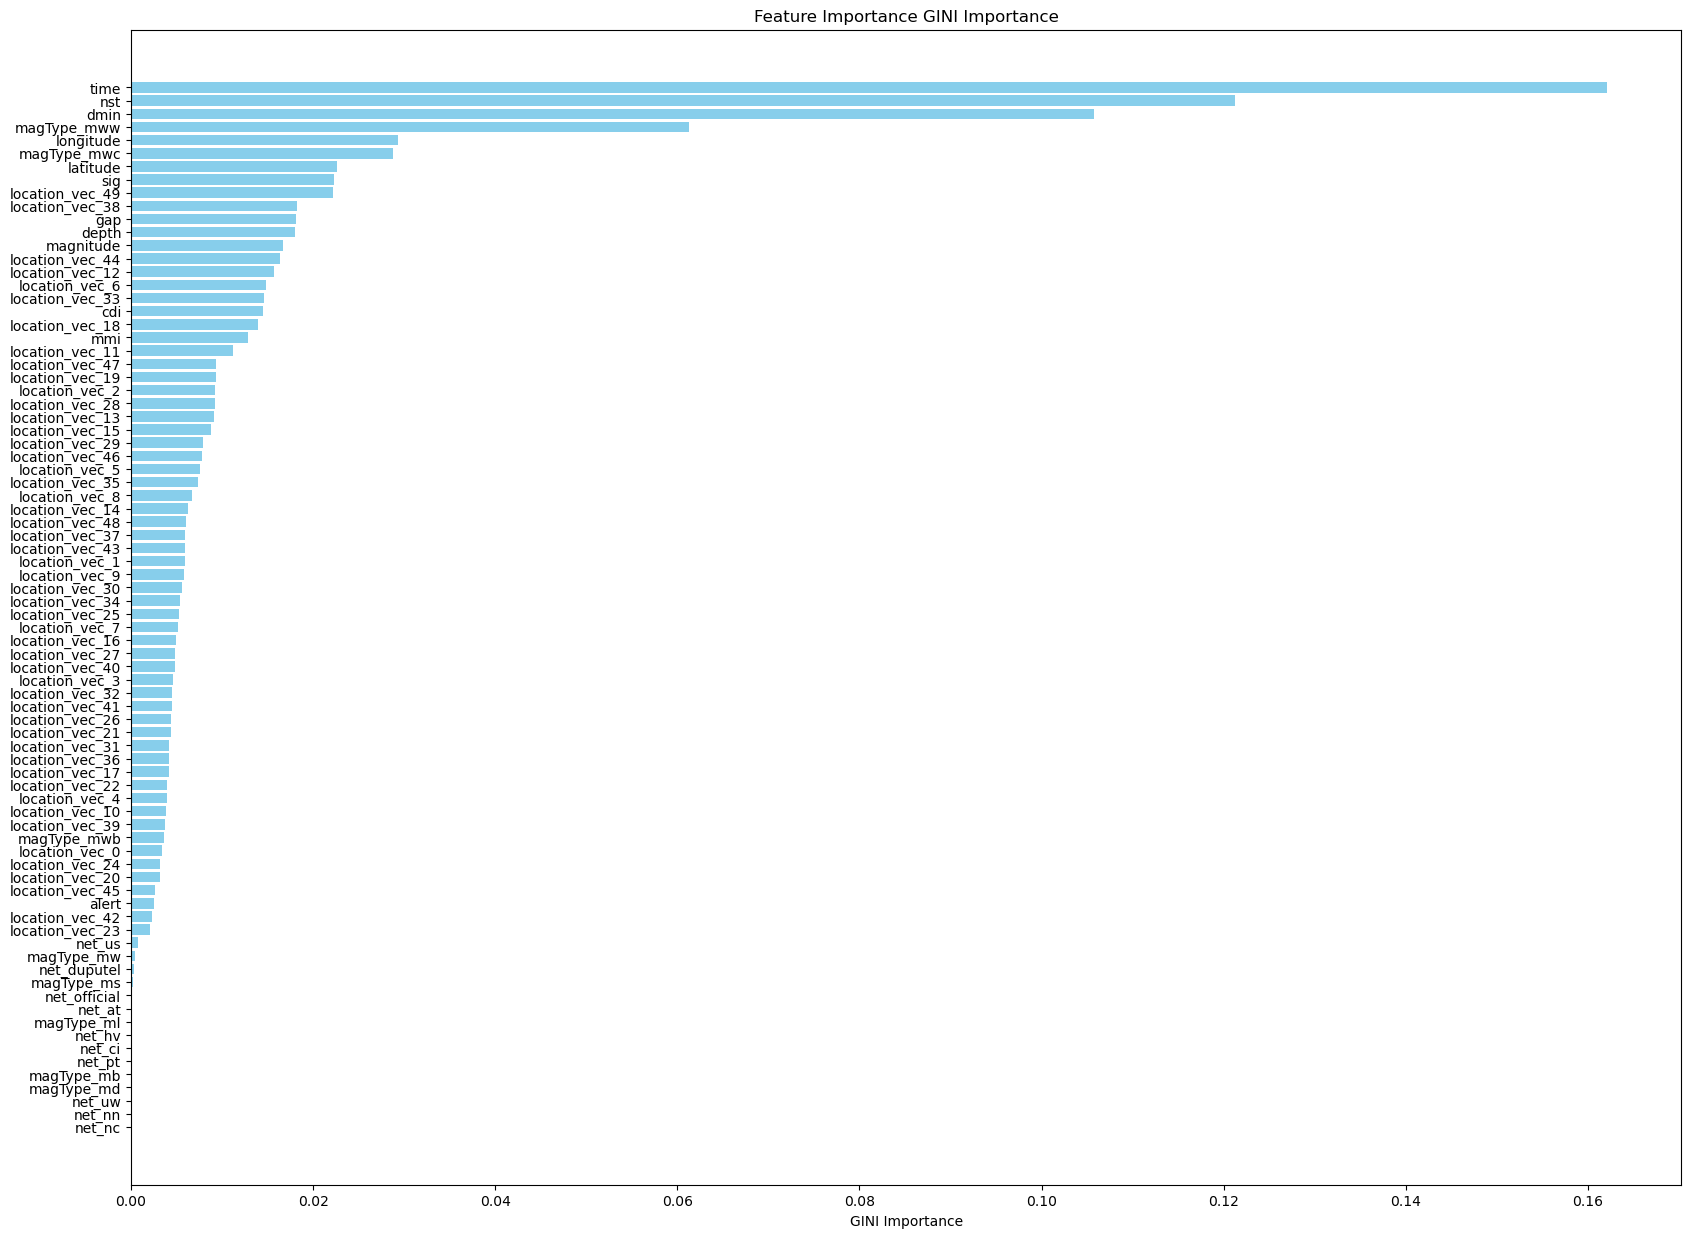

In [ ]:
plt.figure(figsize=(20, 15))
plt.barh(feature_imp_df['Features'], feature_imp_df['GINI Importance'], color='skyblue')
plt.xlabel('GINI Importance')
plt.title('Feature Importance GINI Importance')
plt.gca().invert_yaxis()
plt.show()

Implementation based on: (GeeksForGeeks, 2025)

In [ ]:
# Drop time column first (model was learning temporal patterns instead of earthquake patterns)
X_train = X_train.drop(columns=['time'])
X_test = X_test.drop(columns=['time'])

In [ ]:
X_train_importance = calculate_gini_importance(X_train, y_train)

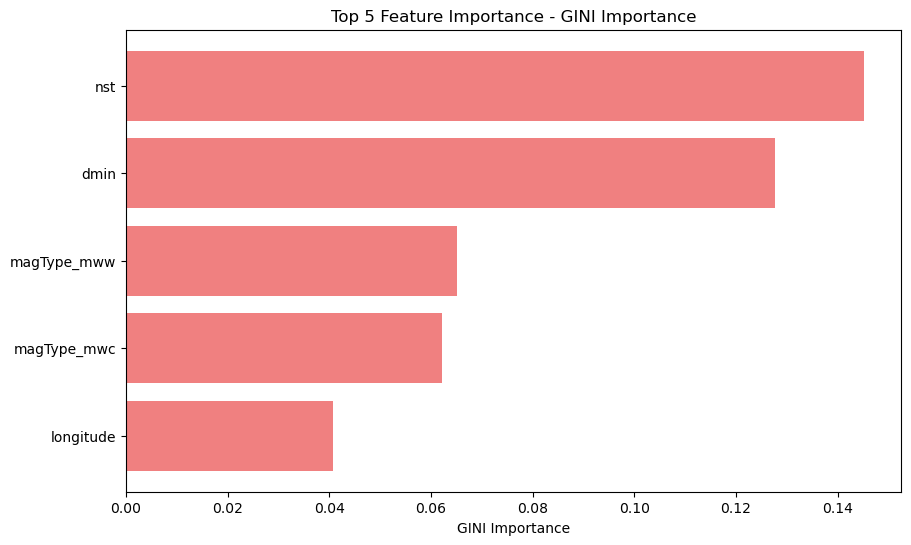

In [ ]:
top_5_features = X_train_importance.head(5)
plt.figure(figsize=(10, 6))
plt.barh(top_5_features['Features'], top_5_features['GINI Importance'], color='lightcoral')
plt.xlabel('GINI Importance')
plt.title('Top 5 Feature Importance - GINI Importance')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
net_columns = []
for col in X_train.columns:
    if col.startswith('net_'):
        net_columns.append(col)
net_importance = X_train_importance[X_train_importance['Features'].isin(net_columns)]
print(net_importance)

        Features  GINI Importance
19        net_us         0.001468
13   net_duputel         0.000713
17  net_official         0.000489
16        net_nn         0.000211
11        net_at         0.000201
18        net_pt         0.000138
15        net_nc         0.000082
14        net_hv         0.000066
20        net_uw         0.000000
12        net_ci         0.000000


In [ ]:
X_train = X_train.drop(columns=net_columns)
X_test = X_test.drop(columns=net_columns)

Total Gini Importance of location vector features: 0.38450780086705977
Gini Importance of dmin feature: 0.1276291476536243


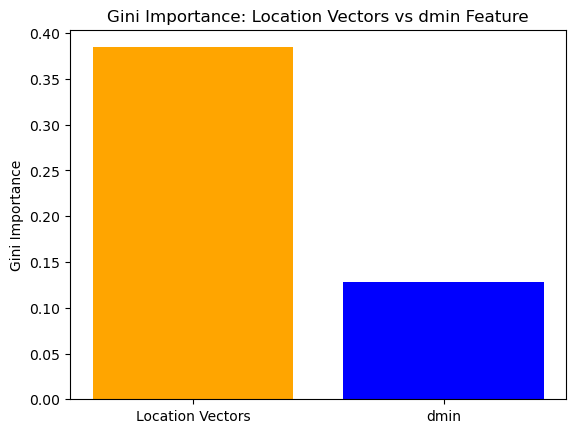

In [ ]:
#Code was sampled from (ChatGPT, 2025)
location_vector_columns = [col for col in X_train.columns if col.startswith('location_vec_')]
location_vector_importance = X_train_importance[X_train_importance['Features'].isin(location_vector_columns)]
total_location_vector_importance = location_vector_importance['GINI Importance'].sum()
print(f'Total Gini Importance of location vector features: {total_location_vector_importance}')
nst_importance = X_train_importance[X_train_importance['Features'] == 'dmin']['GINI Importance'].values[0]
print(f'Gini Importance of dmin feature: {nst_importance}')
plt.bar(['Location Vectors', 'dmin'], [total_location_vector_importance, nst_importance], color=['orange', 'blue'])
plt.title('Gini Importance: Location Vectors vs dmin Feature')
plt.ylabel('Gini Importance')
plt.show()

In [ ]:
magtype_drop_columns = ['magType_mb', 'magType_ms', 'magType_ml', 'magType_md', 'magType_mw', 'magType_mwb'] #dropping low importance features
X_train = X_train.drop(columns=magtype_drop_columns)
X_test = X_test.drop(columns=magtype_drop_columns)

#### Feature engineering

In [ ]:
X_train['general_significance'] = X_train[['sig', 'magnitude', 'cdi', 'mmi']].mean(axis=1)
X_test['general_significance'] = X_test[['sig', 'magnitude', 'cdi', 'mmi']].mean(axis=1)

In [ ]:
X_train['general_position'] = X_train[['latitude', 'longitude', 'depth']].mean(axis=1)
X_test['general_position'] = X_test[['latitude', 'longitude', 'depth']].mean(axis=1)

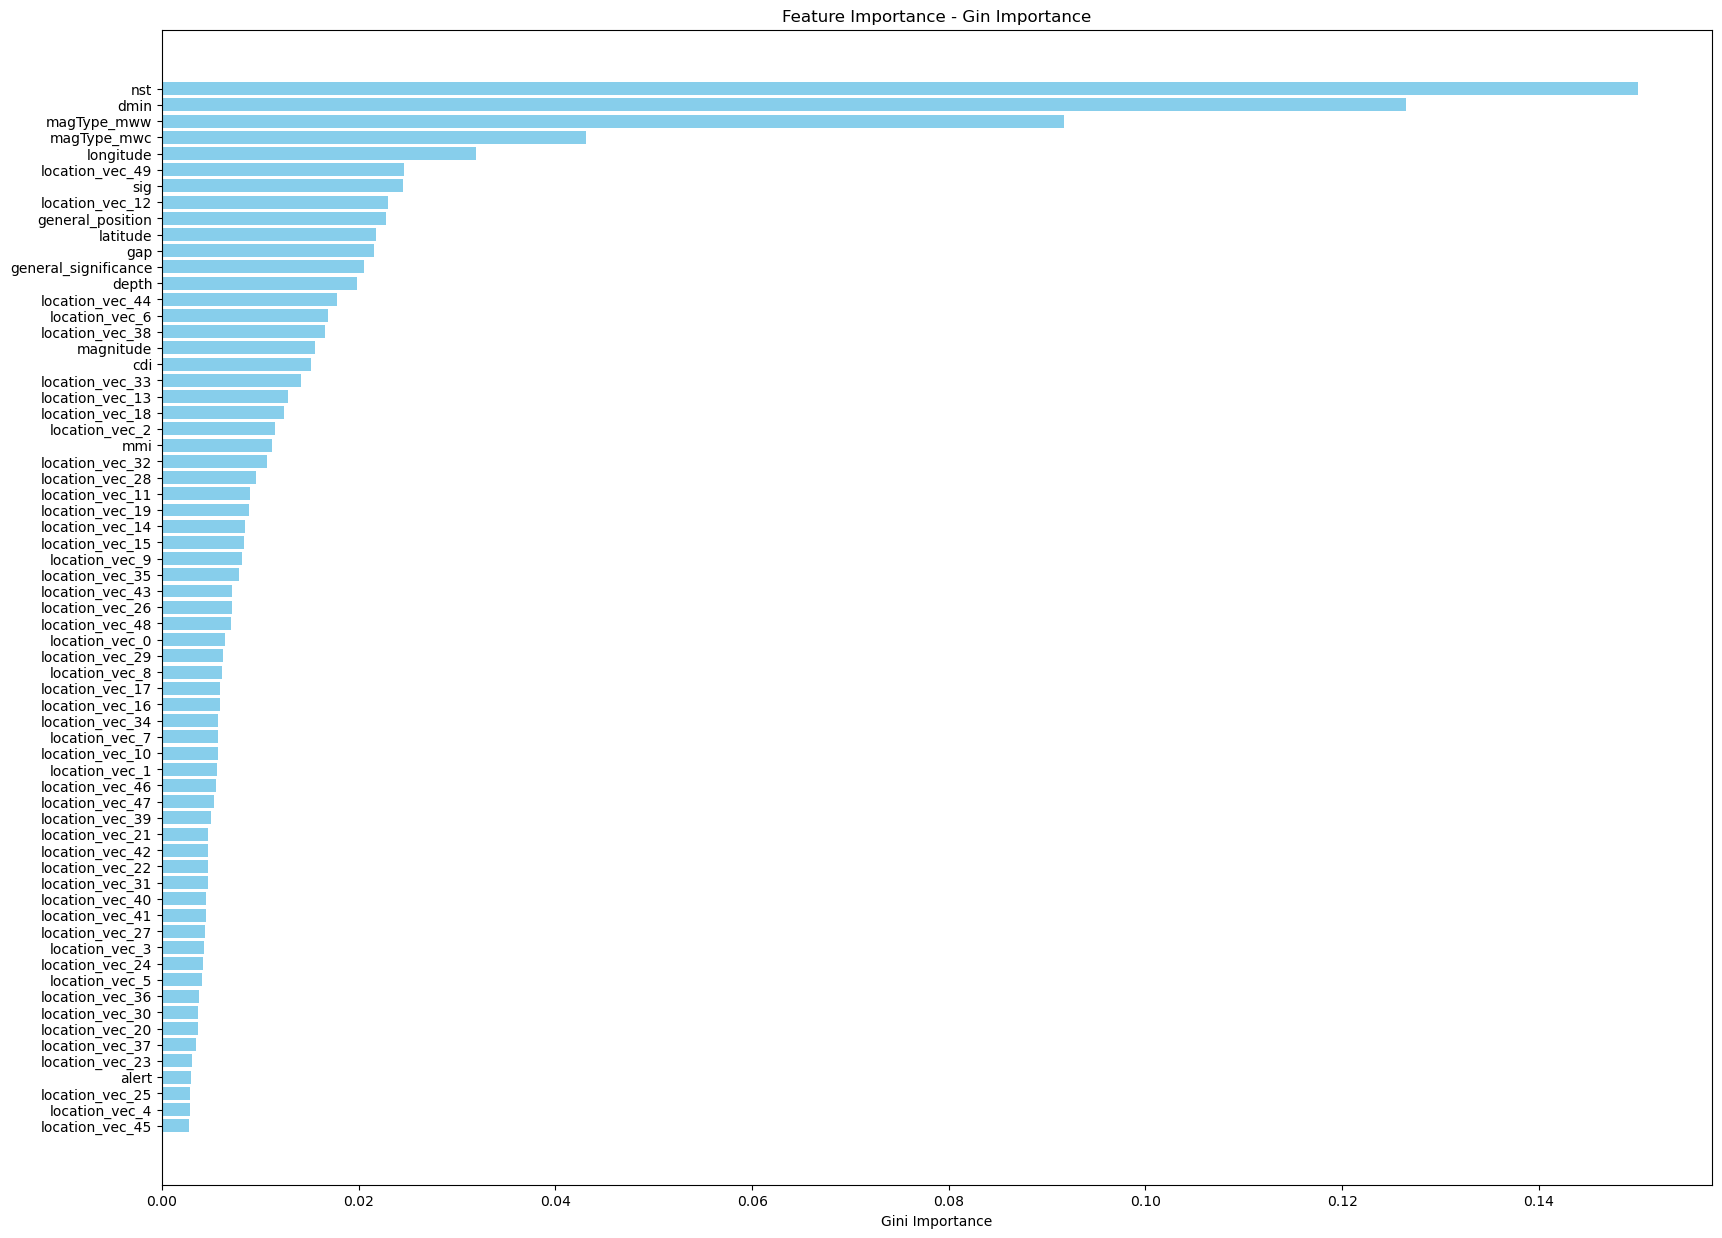

In [ ]:
feature_imp_df = calculate_gini_importance(X_train, y_train)
plt.figure(figsize=(20, 15))
plt.barh(feature_imp_df['Features'], feature_imp_df['GINI Importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gin Importance')
plt.gca().invert_yaxis()
plt.show()

Figure 14: GINI Feature Importance Ranking

In [ ]:
from sklearn.inspection import permutation_importance
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1)
perm_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Permutation Importance': result.importances_mean}).sort_values('Permutation Importance', ascending=False)

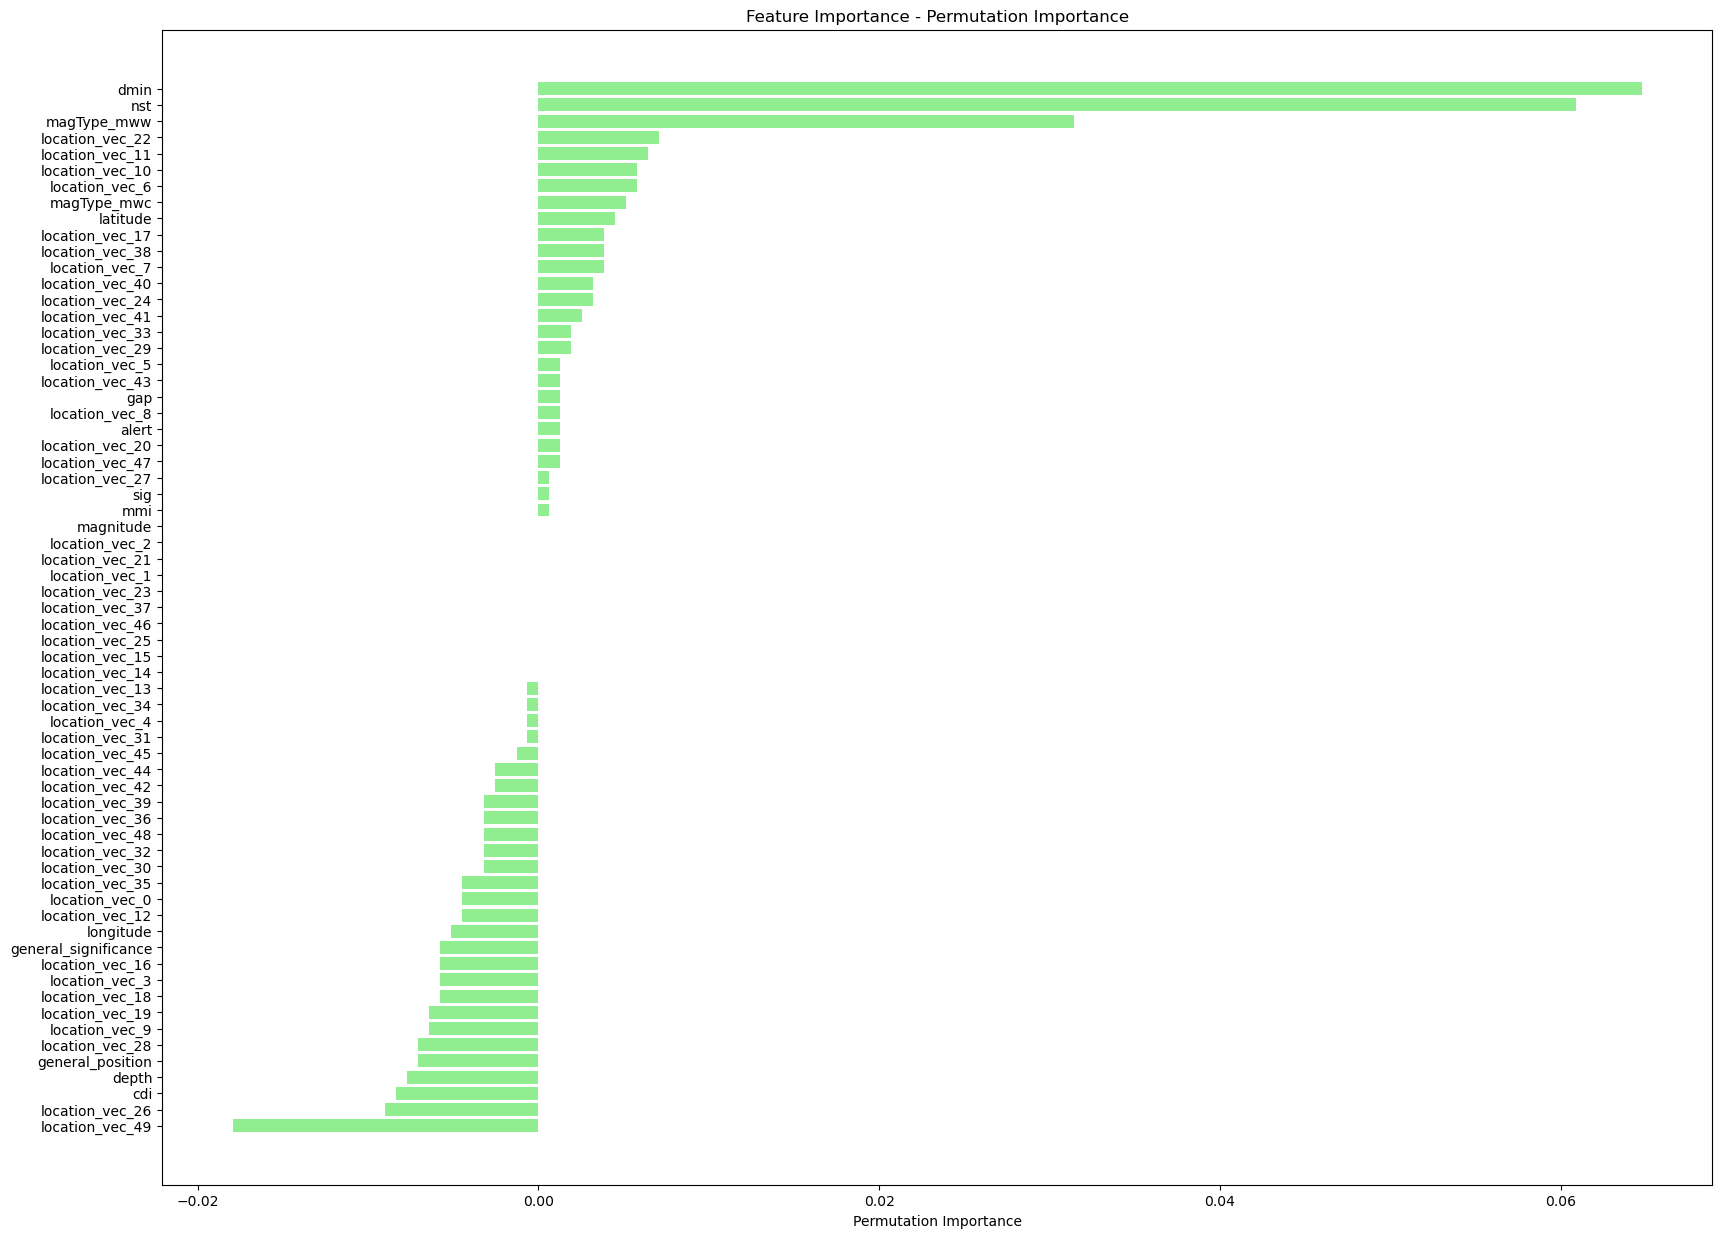

In [ ]:
plt.figure(figsize=(20, 15))
plt.barh(perm_imp_df['Feature'], perm_imp_df['Permutation Importance'], color='lightgreen')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance - Permutation Importance')
plt.gca().invert_yaxis()
plt.show()

Figure 15: Premier interaction feature importance ranking

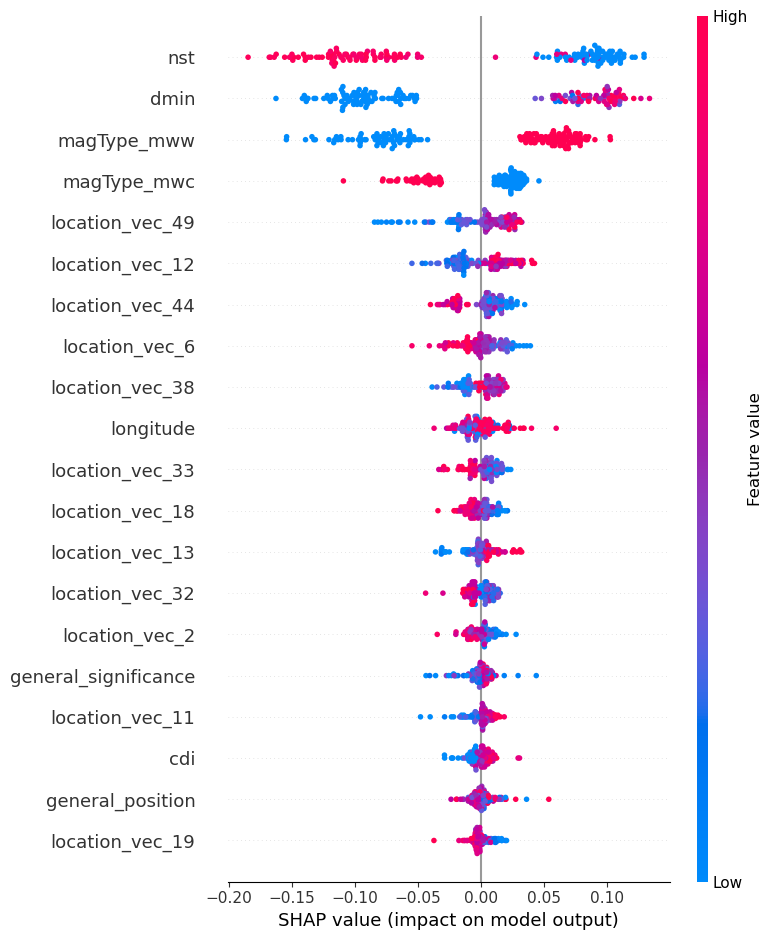

In [ ]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
shap_values_class1 = shap_values[:, :, 1]
shap.summary_plot(shap_values_class1, X_test, plot_type='dot')

Figure 16: SHAP Summary Plot Showing Feature Importance

#### Feature Importance Ranking (SHAP and GINI combined) along with Domain Relevance

Domain relevance dermined by consulting seismology literature on earthquake and tsunami relationships (Lomax, Michelini and Piatanesi, 2011; Wald et al., 2011; United States Geological Survey, 1989) and the table provided by (Chauhan, 2024).

Importance rankings considered both SHAP (figure 16) and GINI (figure 14) feature importance, and (figure 15) premutation importance when dermining overall feature importance.

| **Rank** | **Feature Name**           | **Domain Relevance**                                                |
|----------|----------------------------|---------------------------------------------------------------------|
| 1        | Location Vectors (merged)*  | Encodes geographic patterns and seismic hotspots.                   |
| 2        | dmin                       | Distance to nearest station, affects location accuracy.             |
| 3        | nst                        | Number of reporting stations, higher counts improve reliability.    |
| 4        | magType_mww                | Moment magnitude method, affects magnitude measurement.             |
| 5        | magType_mwc                | Alternatve magnitude method, aids in cross-checking readings.       |
| 6        | longitude                  | Longitude coordinate, key for mapping and regional analysis.        |
| 7        | latitude                   | Latitude coordinate, identifes location.                            |
| 8       | sig                      | Significance of a seismic event determined by muliple sources|
| 9       | cdi                        | Reported intensity, indicates how strongly the quake was felt.      |
| 10      | general_significance       | Mean of `sig`, `magnitude`, `cdi`, and `mmi`;                       |
| 11      | general_position           | Mean of `latitude`, `longitude`, and `depth`                        |


*The merging of location vectors importance is not a prefect metric, however, the reasonable importance ranking of most of the vectors gives confidence to its inclusion.

### An imbalnced dataset

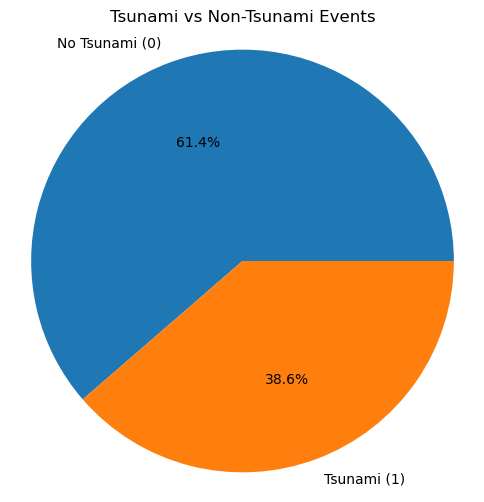

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(y.value_counts(), labels=['No Tsunami (0)', 'Tsunami (1)'], autopct='%1.1f%%') #autopact from Matplotlib documentation (Matplotlib, no date)
plt.title('Tsunami vs Non-Tsunami Events')
plt.axis('equal')
plt.show()

#### Dataset imbalance handling techniques discussion

Examining the chart we can see that our dataset is imbalanced, with a significantly higher proportion of non-tsunami events (0) compared to tsunami events (1). In order to address this class imbalance during model training we will use class weights depending on model compatibility (Google LLC, 2025). SMOTE is another technique for handling imbalanced datasets by generating synthetic samples for the minority class. However, given our small dataset size and high dimensionality due to embedding features, using SMOTE could lead to overfitting and may not be effective as explored by Blagus & Lusa.

(Blagus & Lusa,2013)

## Data limitation and quality issues

Throughout the EDA and data preprocessing steps, we have identified and addressed several data quality issues that could impact our modeling efforts. Our small dataset size of only 779 samples after cleaning limits the complexity of models we can use without overfitting. Of those samples many have a left skew (figure 2), meaning the model may to bias towards lower impact earthquakes, which are less likely to generate tsunamis as acknowledged in (United States Geological Survey, 2023). Our considerable data imputation to resolve our missing data may also introduce some uncertainty, as imputed values may not perfectly reflect true values. Furthermore, relying on a single data source (USGS) may introduce collection bias or limitations based on their data collection methods and coverage, as acknowledged by (United States Geological Survey, 2022).

## Ethics and Privacy Considerations

While our dataset contains no personally identifiable information about individuals, there are still important ethical considerations to keep in mind when working with this data. Especially around deployment, any model used for tsunami prediction must be rigorously tested to avoid false positives or negatives predictions that could lead to unnecessary concern or danger for populations at risk, this will make precision and recall key metrics to focus on during model evaluation. Furthermore, a consideration must be made for accessibility for poorer and remote communities who may not have access to expensive high compute resources.

## Model Selection Rationale

As mentioned in the dataset insights and feature types section, our dataset and `tsunami` target variable are well suited for binary classification models (figure 4). Given the small dataset size and class imbalance, we will focus on models that can handle these challenges effectively and acknowling our small dataset size, we must choose models that are less prone to overfitting. 

### Model 1: Logistic Regression with Class Weights

Logistic regression is a simple but effective method for binary classification (Lee, 2025). It models the probability of a tsunami event using a sigmoid function and allows class weighting to address the dataset’s imbalance (Google LLC, 2025). It also performs well when the number of features compares disproportionately to the number of samples, as in our vectorised dataset, though this typically requires careful regularisation and hyperparameter tuning (Wainwright, Ravikumar & Lafferty, 2006).

Logistic regression is considered to be a less resource intensive algorithm compared to more complex models like neural networks or ensemble methods. This makes it a suitable choice for deployment in low-resource settings, such as remote communities that may not have access to high compute resources as discussed in the ethics and privacy considerations section, (Ayer et al., 2010).

### Model 2: Gradient Boosting classifier

Gradient Boosting Classifier is an ensemble learning method that builds a strong classifier by combining multiple weak decision trees. It iteratively adds trees that correct the errors of previous trees, leading to improved predictive performance (Friedman, 1999). Gradient boosting is less prone to overfitting compared to single decision trees, making it suitable for our small dataset (Natekin & Knoll, 2013). Gradient decision trees can be highly sesnsitive to class imbalance (Luo, 2024), and our sklearn implementation does not allow for class weighting. This is a limiation that could impact model performance on our imbalanced dataset.

Gradient boosting is more computationally intensive than logistic regression, however in comparison to deep learning models, it is still relatively efficient and can be optimized for deployment in low-resource settings with appropriate hyperparameter tuning (Peter et al., 2017).


## Research questions

#### Will a gradient boosting classifier outperform logistic regression in predicting tsunami occurrence following earthquakes based on seismic event characteristics?

This question aims to compare the performance of two different types of model. This question is influenced by our overall goal of building an accurate tsunami prediction model. The answer to this question is of great importaance as selecting the right model architecture is crucial for achieving high predictive accuracy, something that is vital for effective disaster management and early warning systems intent on predicting tsunamis.

#### Which feature will be the most important predictor of tsunami occurrence following earthquakes?

Given the diversity of features in our dataset, this question aims to identify which specific feature has the highest predictive power for tsunami occurrence. Understanding feature importance can provide insights into the underlying factors that contribute to tsunami generation, which is valuable for both scientific understanding and practical applications in tsunami risk assessment.

## Model Training

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
k_folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_recombined, y_recombined = pd.concat([X_train, X_test], axis=0), pd.concat([y_train, y_test], axis=0)

In [ ]:
def overfit_underfit_analysis(train_score, cross_val_score):
    print(f'Training Score: {train_score}')
    print(f'Cross Validation Score: {cross_val_score}')
    if train_score - cross_val_score > 0.01:
        print('The model is overfitting.')
        print(f'Difference: {train_score - cross_val_score}')
    elif cross_val_score - train_score > 0.01:
        print('The model is underfitting.')
        print(f'Difference: {cross_val_score - train_score}')
    else:
        print('The model has a good fit.')

### Model 1: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logclf = LogisticRegression(class_weight='balanced')
logclf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
logclf_train_score = accuracy_score(y_train, logclf.predict(X_train))
print(f'Accuracy Score on Training Set: {logclf_train_score}')

Accuracy Score on Training Set: 0.9004815409309791


In [ ]:
logclf_test_score = accuracy_score(y_test, logclf.predict(X_test))
print(f'Accuracy Score on Test Set: {logclf_test_score}')

Accuracy Score on Test Set: 0.9038461538461539


In [ ]:
predictions_clf = logclf.predict(X_test)
logclf_cross_val_scores = cross_val_score(logclf, X_recombined, y_recombined, cv=k_folds)
print(f'Logistic Regression Cross-Validation Scores: {logclf_cross_val_scores}')
print(f'Logistic Regression Mean CV Score: {logclf_cross_val_scores.mean()}')

Logistic Regression Cross-Validation Scores: [0.84615385 0.84615385 0.83333333 0.88461538 0.79487179 0.91025641
 0.91025641 0.84615385 0.85897436 0.8961039 ]
Logistic Regression Mean CV Score: 0.8626873126873127


In [ ]:
overfit_underfit_analysis(logclf_train_score, logclf_cross_val_scores.mean())

Training Score: 0.9004815409309791
Cross Validation Score: 0.8626873126873127
The model is overfitting.
Difference: 0.037794228243666406


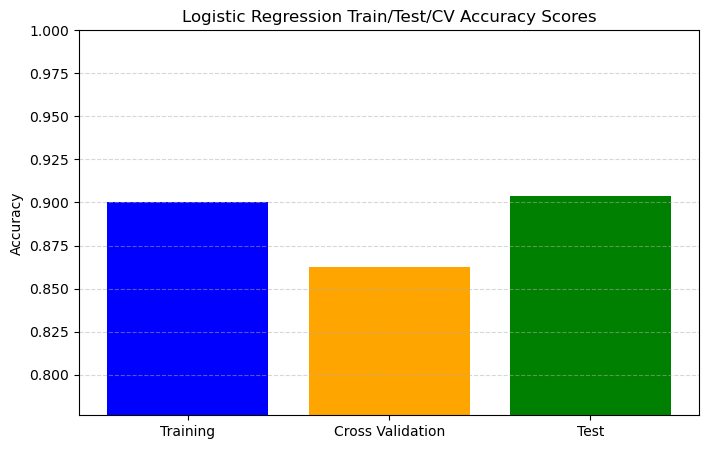

In [ ]:
import matplotlib.pyplot as plt

scores = [
    logclf_train_score,
    logclf_cross_val_scores.mean(),
    logclf_test_score
]

labels = ['Training', 'Cross Validation', 'Test']

plt.figure(figsize=(8,5))
plt.bar(labels, scores, color=['blue', 'orange', 'green'])
plt.ylim(0.9 * min(scores), 1)# (ChatGPT, 2025)
plt.ylabel("Accuracy")
plt.title('Logistic Regression Train/Test/CV Accuracy Scores')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Hyperparameter Tuning for Logistic Regression

Our logistic regression model has achieved a good baseline performance, but there is still room for improvement through hyperparameter tuning, especially around regularization strength as the model appears to be overfitting slightly given the difference between training and cross-validation scores. We will preform a grid search on a selection of hyperparameters to identify the optimal combination that maximizes model performance while minimizing overfitting (figure 19).

#### Exploring C (regularization strength)

In [ ]:
hyperparameters = {
    'penalty':'l2', #regularization type
    'C':0.1, #regularization strength (inverse ratio - smaller values specify stronger regularization)
    'class_weight':'balanced' #address class imbalance (as before)
}

# Previous hyperparameter attempts:
#hyperparameters = {
#    'penalty':'l2',
#    'C':0.1,
#    'class_weight':'balanced'
#}

#hyperparameters = {
#    'penalty':'l2',
#    'C':0.05,
#    'class_weight':'balanced'
#}

#hyperparameters = {
#    'penalty':'l2',
#    'C':0.5,
#    'class_weight':'balanced'
#}

#hyperparameters = {
#    'penalty':'l1',
#    'solver':'saga',
#    'C':0.1,
#    'class_weight':'balanced'
#}

In [ ]:
logclf_tuned = LogisticRegression(**hyperparameters)
logclf_tuned.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
logclf_tuned_train_score = accuracy_score(y_train, logclf_tuned.predict(X_train))
print(f'Accuracy Score on Training Set: {logclf_tuned_train_score}')
logclf_tuned_test_score = accuracy_score(y_test, logclf_tuned.predict(X_test))
print(f'Accuracy Score on Test Set: {logclf_tuned_test_score}')

Accuracy Score on Training Set: 0.8908507223113965
Accuracy Score on Test Set: 0.8846153846153846


In [ ]:
logclf_tuned_cross_val_scores = cross_val_score(logclf_tuned, X_recombined, y_recombined, cv=k_folds)
print(f'Logistic Regression Tuned Cross-Validation Scores: {logclf_tuned_cross_val_scores}')
print(f'Logistic Regression Tuned Mean CV Score: {logclf_tuned_cross_val_scores.mean()}')

Logistic Regression Tuned Cross-Validation Scores: [0.87179487 0.84615385 0.84615385 0.92307692 0.82051282 0.91025641
 0.88461538 0.83333333 0.87179487 0.8961039 ]
Logistic Regression Tuned Mean CV Score: 0.8703796203796206


In [ ]:
overfit_underfit_analysis(logclf_tuned_train_score, logclf_tuned_cross_val_scores.mean())

Training Score: 0.8908507223113965
Cross Validation Score: 0.8703796203796206
The model is overfitting.
Difference: 0.020471101931775926


In [ ]:
print(f'Previous Logistic Regression Mean CV Score: {logclf_cross_val_scores.mean()}')
print(f'Tuned Logistic Regression Mean CV Score: {logclf_tuned_cross_val_scores.mean()}')
print(f'Improvement in Mean CV Score after Tuning: {logclf_tuned_cross_val_scores.mean() - logclf_cross_val_scores.mean()}')

Previous Logistic Regression Mean CV Score: 0.8626873126873127
Tuned Logistic Regression Mean CV Score: 0.8703796203796206
Improvement in Mean CV Score after Tuning: 0.007692307692307887


#### Further Hyperparameter Tuning for general performance improvement (max iterations and tolerance)

In [ ]:
hyperparameters = {
    'C':hyperparameters['C'],
    'class_weight':'balanced',
    'max_iter':100, #increase max iterations to ensure convergence
    'tol':1e-4 #tolerance for stopping criteria (how much improvement is required to continue training)
}
#previously attempted:
#hyperparameters = {
#    'C':0.01, #keep previous best C value
#    'class_weight':'balanced',
#    'max_iter':200,
#    'tol':1e-3
#}

#hyperparameters = {
#    'C':0.01, #keep previous best C value
#    'class_weight':'balanced',
#    'max_iter':300,
#    'tol':1e-5
#}

#hyperparameters = {
#    'C':0.01, #keep previous best C value
#    'class_weight':'balanced',
#    'max_iter':300,
#    'tol':1e-5
#}

#hyperparameters = {
#    'C':0.01, #keep previous best C value
#    'class_weight':'balanced',
#    'max_iter':500,
#    'tol':1e-4
#}   'solver':'liblinear' #Known to work well with small datasets


In [ ]:
logclf_tuned_v2 = LogisticRegression(**hyperparameters)
logclf_tuned_v2.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
logclf_tuned_cross_val_scores_general_performance = cross_val_score(logclf_tuned_v2, X_recombined, y_recombined, cv=k_folds)
print(f'Logistic Regression Tuned Cross-Validation Scores: {logclf_tuned_cross_val_scores_general_performance}')
print(f'Logistic Regression Tuned Mean CV Score: {logclf_tuned_cross_val_scores_general_performance.mean()}')

Logistic Regression Tuned Cross-Validation Scores: [0.87179487 0.84615385 0.84615385 0.92307692 0.82051282 0.91025641
 0.88461538 0.83333333 0.87179487 0.8961039 ]
Logistic Regression Tuned Mean CV Score: 0.8703796203796206


In [ ]:
overfit_underfit_analysis(logclf_tuned_train_score, logclf_tuned_cross_val_scores.mean())

Training Score: 0.8908507223113965
Cross Validation Score: 0.8703796203796206
The model is overfitting.
Difference: 0.020471101931775926


In [ ]:
print(f'Previous Logistic Regression Tuned Mean CV Score: {logclf_tuned_cross_val_scores.mean()}')
print(f'New Tuned Logistic Regression Mean CV Score: {logclf_tuned_cross_val_scores_general_performance.mean()}')
print(f'Improvement in Mean CV Score after Further Tuning: {logclf_tuned_cross_val_scores_general_performance.mean() - logclf_tuned_cross_val_scores.mean()}')

Previous Logistic Regression Tuned Mean CV Score: 0.8703796203796206
New Tuned Logistic Regression Mean CV Score: 0.8703796203796206
Improvement in Mean CV Score after Further Tuning: 0.0


#### Class weight tuning

In [ ]:
hyperparameters = {
    'C':0.01, #keep previous best C value
    'penalty':'l2',
    'class_weight':None, #remove class weights
}

#previously attempted:

# hyperparameters = {
#     'C':0.01, #keep previous best C value
#     'penalty':'l2',
#     'class_weight': {0: 2.0, 1: 1.0}, #adjust class weights to give more importance to non-tsunami class
# }

In [ ]:
logclf_tuned_no_class_weights = LogisticRegression(**hyperparameters)
logclf_tuned_no_class_weights.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
logclf_tuned_no_class_weights_train_score = accuracy_score(y_train, logclf_tuned_no_class_weights.predict(X_train))
print(f'Accuracy Score on Training Set without Class Weights: {logclf_tuned_no_class_weights_train_score}')
logclf_tuned_no_class_weights_test_score = accuracy_score(y_test, logclf_tuned_no_class_weights.predict(X_test))
print(f'Accuracy Score on Test Set without Class Weights: {logclf_tuned_no_class_weights_test_score}')

Accuracy Score on Training Set without Class Weights: 0.8812199036918138
Accuracy Score on Test Set without Class Weights: 0.8782051282051282


In [ ]:
logclf_tuned_no_class_weights_cross_val_scores = cross_val_score(logclf_tuned_no_class_weights, X_recombined, y_recombined, cv=k_folds)
print(f'Logistic Regression Tuned without Class Weights Cross-Validation Scores: {logclf_tuned_no_class_weights_cross_val_scores}')
print(f'Logistic Regression Tuned without Class Weights Mean CV Score: {logclf_tuned_no_class_weights_cross_val_scores.mean()}')

Logistic Regression Tuned without Class Weights Cross-Validation Scores: [0.83333333 0.87179487 0.84615385 0.88461538 0.83333333 0.91025641
 0.8974359  0.84615385 0.8974359  0.8961039 ]
Logistic Regression Tuned without Class Weights Mean CV Score: 0.8716616716616716


In [ ]:
print(f'Previous Best Tuned Logistic Regression Mean CV Score: {logclf_tuned_cross_val_scores.mean()}')
print(f'Logistic Regression without Class Weights Mean CV Score: {logclf_tuned_no_class_weights_cross_val_scores.mean()}')
print(f'Change in Mean CV Score after Removing Class Weights: {logclf_tuned_no_class_weights_cross_val_scores.mean() - logclf_tuned_cross_val_scores.mean()}')

Previous Best Tuned Logistic Regression Mean CV Score: 0.8703796203796206
Logistic Regression without Class Weights Mean CV Score: 0.8716616716616716
Change in Mean CV Score after Removing Class Weights: 0.0012820512820510555


#### Grid Search for Hyperparameter Optimization and Visualization

In [ ]:
#TODO: Add to contents section

In [ ]:
hyperparameters = {
    'C':[0.005,0.01, 0.1, 0.3, 0.5], 
    'penalty':['l2'], #keep l2 regularization
    'class_weight':['balanced'], #keep class weights to address class imbalance
    'max_iter':[100, 200, 300, 500], #vary max iterations
    'tol':[1e-2,1e-3, 1e-4, 1e-5], #vary tolerance
}

results = {}
for param, values in hyperparameters.items():
    scores = []
    for val in values:
        params = {param: None}
        params[param] = val
        model = LogisticRegression(**params)
        cv = cross_val_score(model, X_recombined, y_recombined, cv=k_folds)
        scores.append(cv.mean())
    results[param] = (values, scores)

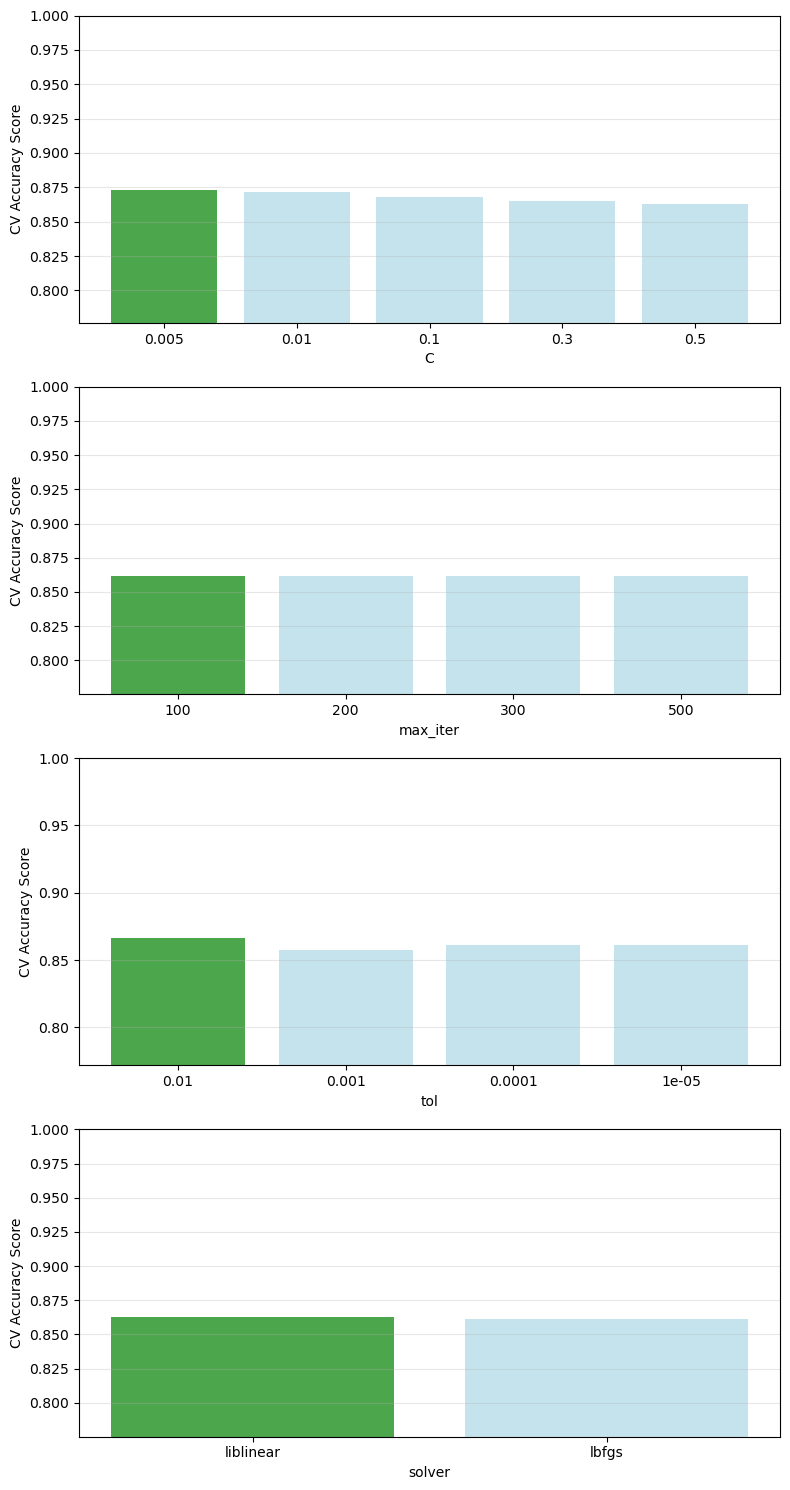

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(8, 15))

changable_hyperparemters = [param for param in hyperparameters.keys() if param != 'penalty' and param != 'class_weight']

for i, param in enumerate(changable_hyperparemters):

    scores = results[param][1]
    best_idx = scores.index(max(scores)) # (ChatGPT, 2025)
    colors = ['green' if j == best_idx else 'lightblue' for j in range(len(scores))] # (ChatGPT, 2025)
    axes[i].bar(range(len(results[param][0])), results[param][1], color=colors, alpha=0.7)
    axes[i].set_xlabel(param)
    axes[i].set_ylabel('CV Accuracy Score')
    axes[i].set_xticks(range(len(results[param][0])))
    axes[i].set_xticklabels(results[param][0])
    axes[i].set_ylim(0.9 * min(results[param][1]), 1)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Grid Search for Hyperparameter Optimization


| Hyperparameter    | What it does                                                                                                                                                                                         |
|------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `C`              | oppersite of regularization strength. Smaller values, stronger regularization, simpler model, less overfiting. Larger values, weaker regularization, more complex model, higher risk of overfitting. |
| `penalty`        | Type of regularization applied. `'l2'` adds a penalty on squared weights to shrink them and reduce overfitting.
| `class_weight`   | Adjusts the importance of each class to handle imbalance. `'balanced'` automatially scales weights inversely to class frequency.                                                                     |
| `max_iter`       | maximum number of iterations for solver convergence. Too low, may not converge, higher values allow full optimization but slightly slower training.                                                  |
| `tol`            | Tolerance for stopping criteria. Smaller values, solver runs longer for precise convergence, can slightly overfit. Larger values, stops earlier, may underfit but trains faster.                     |
| `solver`         | our choice model type used to optimize the loss. `'liblinear'`, good for small datasets and supports L1 & L2 regularization                                                                          |

Figure 19: Hyperparameter explanations for Logistic Regression model

We will use our experiments from previous hyperparameter tuning attempts to inform our grid search.

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(LogisticRegression(class_weight='balanced'), hyperparameters, cv=k_folds)
grid_search.fit(X_train, y_train)
grid_searched_best_model = grid_search.best_estimator_

In [ ]:
print(f'Best Hyperparameters from Grid Search: {grid_search.best_params_}')

Best Hyperparameters from Grid Search: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.01}


In [ ]:
#display grid search results
best_params = pd.DataFrame(grid_search.best_params_, index=[0])
print(f'Grid Search Best Hyperparameters:\n{best_params}')

Grid Search Best Hyperparameters:
      C class_weight  max_iter penalty solver   tol
0  0.01     balanced       100      l2  lbfgs  0.01


Our grid search is selecting within the region of our previous best hyperparameters, meaning its unlikely to yield significant improvements. However, we will still evaluate the grid searched model to confirm its status as our best model.

In [ ]:
grid_searched_logclf_train_score = accuracy_score(y_train, grid_searched_best_model.predict(X_train))
print(f'Accuracy Score on Training Set: {grid_searched_logclf_train_score}')
grid_searched_logclf_test_score = accuracy_score(y_test, grid_searched_best_model.predict(X_test))
print(f'Accuracy Score on Test Set: {grid_searched_logclf_test_score}')
grid_searched_logclf_cross_val_scores = cross_val_score(grid_searched_best_model, X_recombined, y_recombined, cv=k_folds)
print(f'Grid Searched Logistic Regression Cross-Validation Scores: {grid_searched_logclf_cross_val_scores}')
print(f'Grid Searched Logistic Regression Mean CV Score: {grid_searched_logclf_cross_val_scores.mean()}')

Accuracy Score on Training Set: 0.8876404494382022
Accuracy Score on Test Set: 0.8910256410256411
Grid Searched Logistic Regression Cross-Validation Scores: [0.84615385 0.84615385 0.83333333 0.91025641 0.85897436 0.87179487
 0.87179487 0.84615385 0.88461538 0.8961039 ]
Grid Searched Logistic Regression Mean CV Score: 0.8665334665334665


In [ ]:
#compare with previous best tuned model
print(f'Previous Best Tuned Logistic Regression Mean CV Score: {logclf_tuned_cross_val_scores.mean()}')
print(f'Grid Searched Logistic Regression Mean CV Score: {grid_searched_logclf_cross_val_scores.mean()}')
print(f'Improvement in Mean CV Score after Grid Search: {grid_searched_logclf_cross_val_scores.mean() - logclf_tuned_cross_val_scores.mean()}')

Previous Best Tuned Logistic Regression Mean CV Score: 0.8703796203796206
Grid Searched Logistic Regression Mean CV Score: 0.8665334665334665
Improvement in Mean CV Score after Grid Search: -0.0038461538461540545


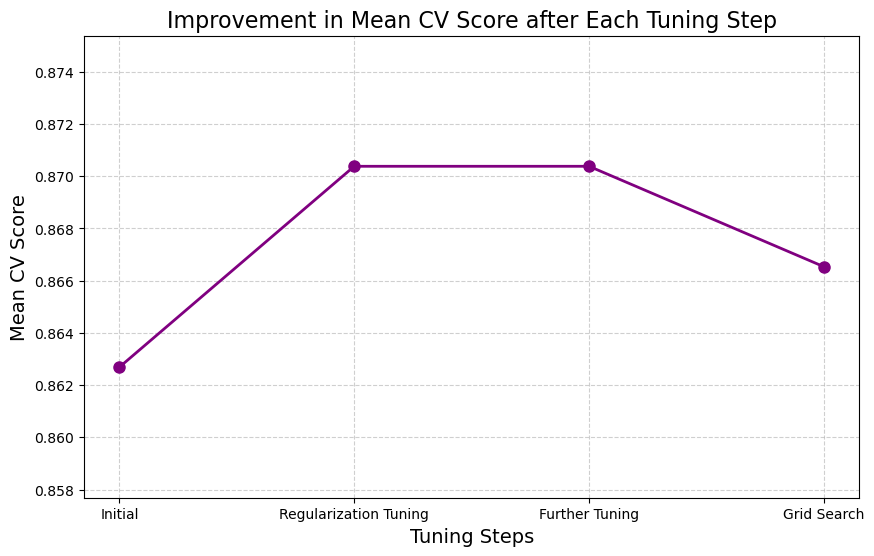

In [ ]:
import matplotlib.pyplot as plt

tuning_steps = ['Initial', 'Regularization Tuning', 'Further Tuning', 'Grid Search']
mean_cv_scores = [
    logclf_cross_val_scores.mean(),
    logclf_tuned_cross_val_scores.mean(),
    logclf_tuned_cross_val_scores_general_performance.mean(),
    grid_searched_logclf_cross_val_scores.mean()
]
plt.figure(figsize=(10,6))
plt.plot(tuning_steps, mean_cv_scores, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

plt.title('Improvement in Mean CV Score after Each Tuning Step', fontsize=16)
plt.xlabel('Tuning Steps', fontsize=14)
plt.ylabel('Mean CV Score', fontsize=14)

# Zoom in on the range of scores to make small improvements more visible
plt.ylim(min(mean_cv_scores)-0.005, max(mean_cv_scores)+0.005) #(ChatGPT, 2025)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
print("Logistic Regression Hyperparameter Tuning Summary:")
print(f'Initial Mean CV Score: {logclf_cross_val_scores.mean()}')
print(f'After Regularization Tuning Mean CV Score: {logclf_tuned_cross_val_scores.mean()}')
print(f'After Further Tuning Mean CV Score: {logclf_tuned_cross_val_scores_general_performance.mean()}')
print(f'After Grid Search Mean CV Score: {grid_searched_logclf_cross_val_scores.mean()}')
overfit_underfit_analysis(grid_searched_logclf_train_score, grid_searched_logclf_cross_val_scores.mean())

Logistic Regression Hyperparameter Tuning Summary:
Initial Mean CV Score: 0.8626873126873127
After Regularization Tuning Mean CV Score: 0.8703796203796206
After Further Tuning Mean CV Score: 0.8703796203796206
After Grid Search Mean CV Score: 0.8665334665334665
Training Score: 0.8876404494382022
Cross Validation Score: 0.8665334665334665
The model is overfitting.
Difference: 0.02110698290473567


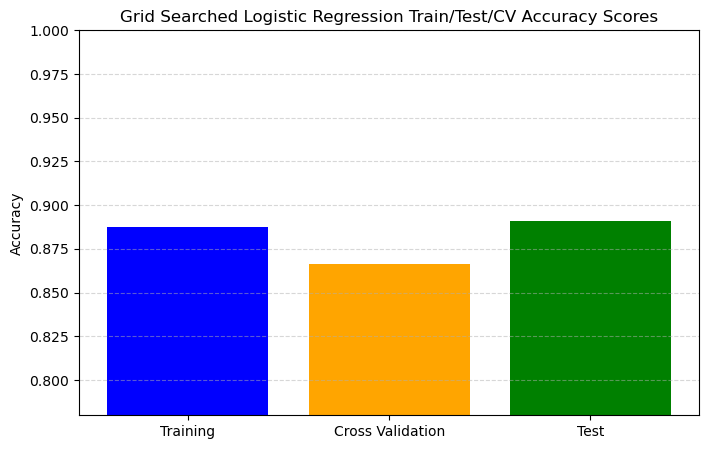

In [ ]:
import matplotlib.pyplot as plt

scores = [
    grid_searched_logclf_train_score,
    grid_searched_logclf_cross_val_scores.mean(),
    grid_searched_logclf_test_score
]

labels = ['Training', 'Cross Validation', 'Test']

plt.figure(figsize=(8,5))
plt.bar(labels, scores, color=['blue', 'orange', 'green'])
plt.ylim(0.9 * min(scores), 1)# (ChatGPT, 2025)
plt.ylabel("Accuracy")
plt.title("Grid Searched Logistic Regression Train/Test/CV Accuracy Scores")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
logclf_top_perf = grid_searched_best_model #top preforming model after hyperparameter tuning (identical to previous tuned model)

In [ ]:
with open('logistic_regression_best_cv_score.txt', 'w') as f:
    f.write(f'Best Logistic Regression Mean CV Score: {grid_searched_logclf_cross_val_scores.mean()}')
    for i, score in enumerate(grid_searched_logclf_cross_val_scores):
        f.write(f'\nFold {i+1} CV Score: {score}')
    f.close()

### Model 2: Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
gbc_train_score = gbc.score(X_train, y_train)
print(f'Accuracy Score on Training Set: {gbc_train_score}')

Accuracy Score on Training Set: 0.9839486356340289


In [ ]:
gbc_test_score = gbc.score(X_test, y_test)
print(f'Accuracy Score on Test Set: {gbc_test_score}')

Accuracy Score on Test Set: 0.8974358974358975


In [ ]:
predictions_gbc = gbc.predict(X_test)
gbc_cross_val_scores = cross_val_score(gbc, X_recombined, y_recombined, cv=k_folds)
print(f'Gradient Boosting Classifier Cross-Validation Scores: {gbc_cross_val_scores}')
print(f'Gradient Boosting Classifier Mean CV Score: {gbc_cross_val_scores.mean()}')

Gradient Boosting Classifier Cross-Validation Scores: [0.88461538 0.8974359  0.88461538 0.85897436 0.88461538 0.93589744
 0.91025641 0.91025641 0.88461538 0.90909091]
Gradient Boosting Classifier Mean CV Score: 0.896037296037296


In [ ]:
overfit_underfit_analysis(gbc_train_score, gbc_cross_val_scores.mean())

Training Score: 0.9839486356340289
Cross Validation Score: 0.896037296037296
The model is overfitting.
Difference: 0.08791133959673292


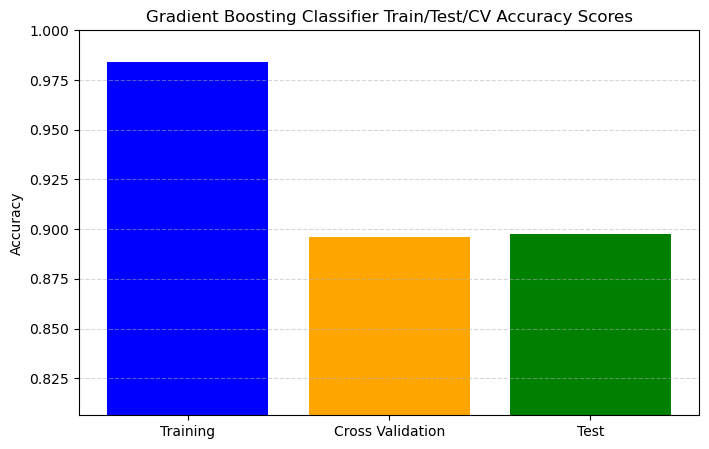

In [ ]:
import matplotlib.pyplot as plt

scores = [
    gbc_train_score,
    gbc_cross_val_scores.mean(),
    gbc_test_score
]

labels = ['Training', 'Cross Validation', 'Test']

plt.figure(figsize=(8,5))
plt.bar(labels, scores, color=['blue', 'orange', 'green'])
plt.ylim(0.9 * min(scores), 1)# (ChatGPT, 2025)
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Classifier Train/Test/CV Accuracy Scores")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Hyperparameter Tuning for Gradient Boosting Classifier

Our analysis of the gradient boosting classifier has revealed some considerable overfitting, as indicated by the higher training score compared to cross-validation score. To combat this, we will explore hyperparameter tuning to improve model generalization. This will require changes to tree depth and number of estimators (number of trees in our ensemble). This will help us find the optimal balance between bias and variance, allowing for better performance on unseen data. We will use a grid search to systematically explore combinations of these hyperparameters and identify the best configuration for our model (figure 20).

#### Tree depth and number of estimators tuning

In [ ]:
hyperparameters = {
    'max_depth': 6, #limit tree depth to reduce overfitting
    'n_estimators': 150,#reduce number of trees to prevent overfitting
}

# Previous hyperparameter attempts:
# hyperparameters = {
#     'max_depth': 5,
#     'n_estimators': 200,
# }
# hyperparameters = {
#     'max_depth': 4,
#     'n_estimators': 100,
# }
# hyperparameters = {
#     'max_depth': 3,
#     'n_estimators': 200,
# }
# hyperparameters = {
#     'max_depth': 7,
#     'n_estimators': 200,
# }

In [ ]:
gbc_tuned = GradientBoostingClassifier(**hyperparameters)
gbc_tuned.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


In [ ]:
gbc_tuned_train_score = gbc_tuned.score(X_train, y_train)
print(f'Accuracy Score on Training Set: {gbc_tuned_train_score}')
gbc_tuned_test_score = accuracy_score(y_test, gbc_tuned.predict(X_test))
print(f'Accuracy Score on Test Set: {gbc_tuned_test_score}')

Accuracy Score on Training Set: 1.0
Accuracy Score on Test Set: 0.8910256410256411


In [ ]:
gbc_tuned_cross_val_scores = cross_val_score(gbc_tuned, X_recombined, y_recombined, cv=k_folds)
print(f'Gradient Boosting Classifier Tuned Cross-Validation Scores: {gbc_tuned_cross_val_scores}')
print(f'Gradient Boosting Classifier Tuned Mean CV Score: {gbc_tuned_cross_val_scores.mean()}')

Gradient Boosting Classifier Tuned Cross-Validation Scores: [0.91025641 0.91025641 0.83333333 0.84615385 0.8974359  0.93589744
 0.88461538 0.87179487 0.91025641 0.90909091]
Gradient Boosting Classifier Tuned Mean CV Score: 0.8909090909090909


In [ ]:
overfit_underfit_analysis(gbc_tuned_train_score, gbc_tuned_cross_val_scores.mean())

Training Score: 1.0
Cross Validation Score: 0.8909090909090909
The model is overfitting.
Difference: 0.10909090909090913


In [ ]:
print(f'Previous Gradient Boosting Classifier Mean CV Score: {gbc_cross_val_scores.mean()}')
print(f'Tuned Gradient Boosting Classifier Mean CV Score: {gbc_tuned_cross_val_scores.mean()}')
print(f'Improvement in Mean CV Score after Tuning: {gbc_tuned_cross_val_scores.mean() - gbc_cross_val_scores.mean()}')

Previous Gradient Boosting Classifier Mean CV Score: 0.896037296037296
Tuned Gradient Boosting Classifier Mean CV Score: 0.8909090909090909
Improvement in Mean CV Score after Tuning: -0.00512820512820511


#### Grid Search for Hyperparameter Optimization and Visualization

In [ ]:
#TODO: Add to contents section

In [ ]:
hyperparameters = {
    'max_depth':[5,6,7,8],
    'n_estimators':[100,150,200],
    'min_samples_split':[4,8],
    'min_samples_leaf':[2,4],
    'max_leaf_nodes':[20,30,40],
    'learning_rate':[0.01,0.05,0.1]
}

results = {}
for param, values in hyperparameters.items():
    scores = []
    for val in values:
        params = {param: None}
        params[param] = val
        model = GradientBoostingClassifier(**params)
        cv = cross_val_score(model, X_recombined, y_recombined, cv=k_folds)
        scores.append(cv.mean())
    results[param] = (values, scores)

KeyboardInterrupt: 

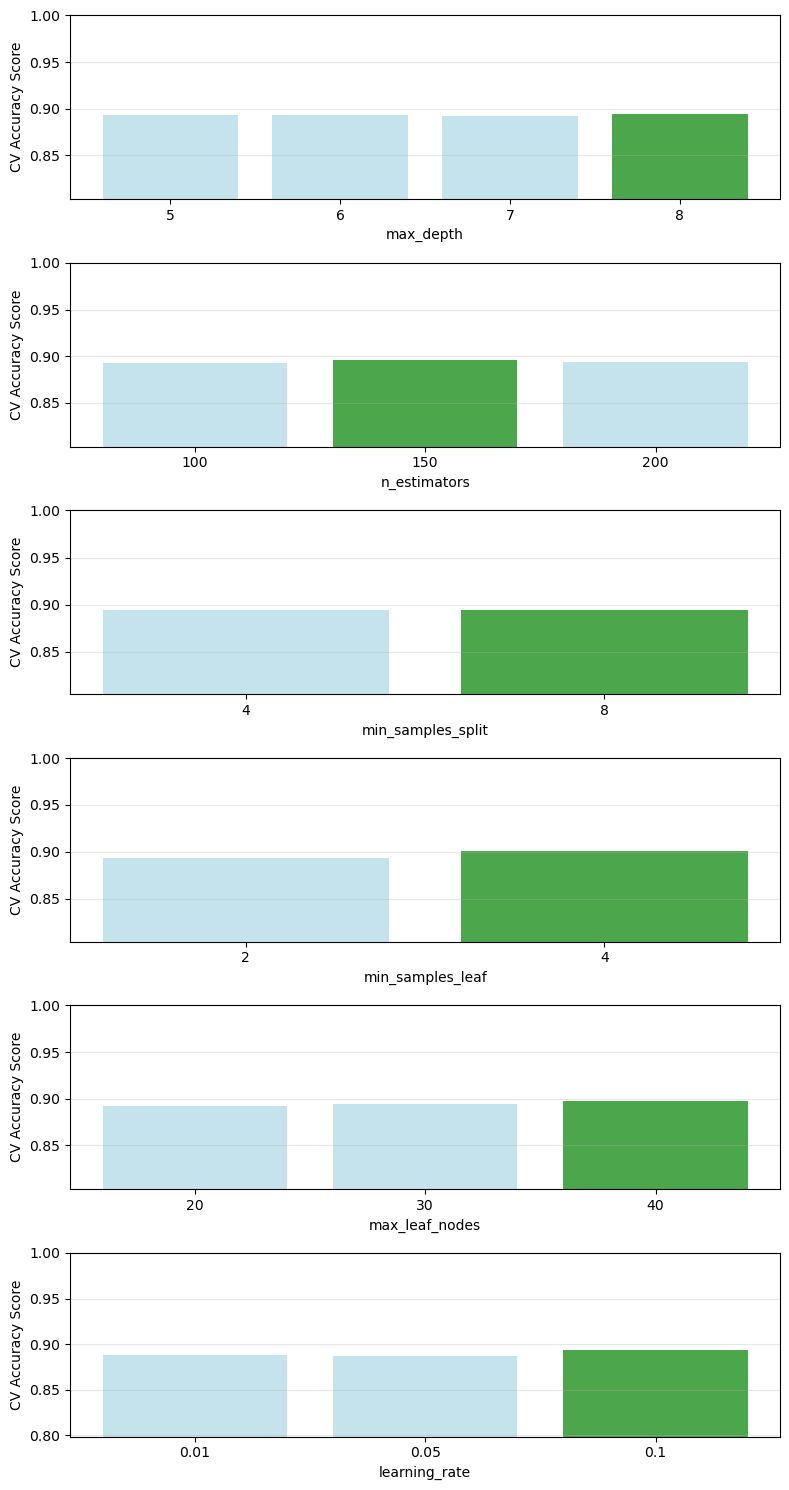

In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(8, 15))

for i, param in enumerate(hyperparameters.keys()):
    scores = results[param][1]
    best_idx = scores.index(max(scores)) #(ChatGPT, 2025)
    colors = ['green' if j == best_idx else 'lightblue' for j in range(len(scores))] # (ChatGPT, 2025)
    axes[i].bar(range(len(results[param][0])), results[param][1], color=colors, alpha=0.7)
    axes[i].set_xlabel(param)
    axes[i].set_ylabel('CV Accuracy Score')
    axes[i].set_xticks(range(len(results[param][0])))
    axes[i].set_xticklabels(results[param][0])
    axes[i].set_ylim(0.9 * min(results[param][1]), 1)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Grid Search for Hyperparameter Optimization

| Hyperparameter           | What it does                                                                                                                    |
|--------------------------|---------------------------------------------------------------------------------------------------------------------------------|
| `max_depth`              | Limits the maximum depth of each tree. Deeper trees capture more complex patterns but are more likely to overfit.               |
| `max_leaf_nodes`         | sets the maximum number of leaf nodes per tree. More leaves allow finer patterns, increasing overfitting risk.                  |
| `min_samples_leaf`       | Minimum number of samples required at a leaf node. Higher values prevent very small leaves, reducing overfitting.               |
| `min_samples_split`      | Minimum number of samples required to split a node. Larger values prevent splits on tiny nodes, reducing overfitting.           |
| `learning_rate`          | Shrinks contribution of each tree in the ensemble. Smaller values slow learning but reduce overfitting.                         |
| `n_estimators`           | Number of boosting iterations (trees). More trees can increase complexity and overfitting, especially with high learning rates. |

Figure 20: Gradient Boosting Classifier Hyperparameter Explanations

We will use the knowledge gained from our previous hyperparameter tuning attempts to guide our grid search.

In [ ]:
grid_search_gbc = GridSearchCV(GradientBoostingClassifier(), hyperparameters, cv=k_folds)
grid_search_gbc.fit(X_train, y_train)
grid_searched_best_model_gbc = grid_search_gbc.best_estimator_

In [ ]:
print(f'Best Hyperparameters from Grid Search: {grid_search_gbc.best_params_}')
grid_search_gbc_train_score = grid_searched_best_model_gbc.score(X_train, y_train)
print(f'Accuracy Score on Training Set: {grid_search_gbc_train_score}')
grid_search_gbc_test_score = accuracy_score(y_test, grid_searched_best_model_gbc.predict(X_test))
print(f'Accuracy Score on Test Set: {grid_search_gbc_test_score}')
grid_searched_gbc_cross_val_scores = cross_val_score(grid_searched_best_model_gbc, X_recombined, y_recombined, cv=k_folds)
print(f'Grid Searched Gradient Boosting Classifier Cross-Validation Scores: {grid_searched_gbc_cross_val_scores}')
print(f'Grid Searched Gradient Boosting Classifier Mean CV Score: {grid_searched_gbc_cross_val_scores.mean()}')
overfit_underfit_analysis(grid_search_gbc_train_score, grid_searched_gbc_cross_val_scores.mean())

Best Hyperparameters from Grid Search: {'learning_rate': 0.05, 'max_depth': 6, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 100}
Accuracy Score on Training Set: 1.0
Accuracy Score on Test Set: 0.8589743589743589
Grid Searched Gradient Boosting Classifier Cross-Validation Scores: [0.87179487 0.91025641 0.88461538 0.85897436 0.88461538 0.96153846
 0.88461538 0.85897436 0.93589744 0.93506494]
Grid Searched Gradient Boosting Classifier Mean CV Score: 0.8986346986346986
Training Score: 1.0
Cross Validation Score: 0.8986346986346986
The model is overfitting.
Difference: 0.10136530136530142


In [ ]:
#display grid search results
best_params = pd.DataFrame(grid_search.best_params_, index=[0])
print(f'Grid Search Best Hyperparameters:\n{best_params}')

Grid Search Best Hyperparameters:
      C class_weight  max_iter penalty solver    tol
0  0.01     balanced       100      l2  lbfgs  0.001


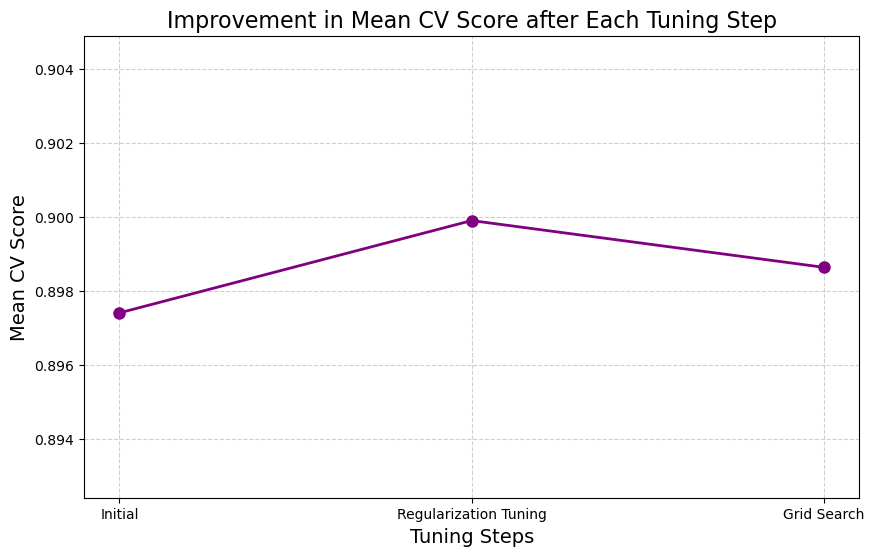

In [ ]:
import matplotlib.pyplot as plt

tuning_steps = ['Initial', 'Regularization Tuning', 'Grid Search']
mean_cv_scores = [
    gbc_cross_val_scores.mean(),
    gbc_tuned_cross_val_scores.mean(),
    grid_searched_gbc_cross_val_scores.mean()
]
plt.figure(figsize=(10,6))
plt.plot(tuning_steps, mean_cv_scores, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

plt.title('Improvement in Mean CV Score after Each Tuning Step', fontsize=16)
plt.xlabel('Tuning Steps', fontsize=14)
plt.ylabel('Mean CV Score', fontsize=14)

# Zoom in on the range of scores to make small improvements more visible
plt.ylim(min(mean_cv_scores)-0.005, max(mean_cv_scores)+0.005) #(ChatGPT, 2025)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
print(f'Previous Best Tuned Gradient Boosting Classifier Mean CV Score: {gbc_tuned_cross_val_scores.mean()}')
print(f'Grid Searched Gradient Boosting Classifier Mean CV Score: {grid_searched_gbc_cross_val_scores.mean()}')
print(f'Improvement in Mean CV Score after Grid Search: {grid_searched_gbc_cross_val_scores.mean() - gbc_tuned_cross_val_scores.mean()}')

Previous Best Tuned Gradient Boosting Classifier Mean CV Score: 0.8999000999000998
Grid Searched Gradient Boosting Classifier Mean CV Score: 0.8986346986346986
Improvement in Mean CV Score after Grid Search: -0.0012654012654012003


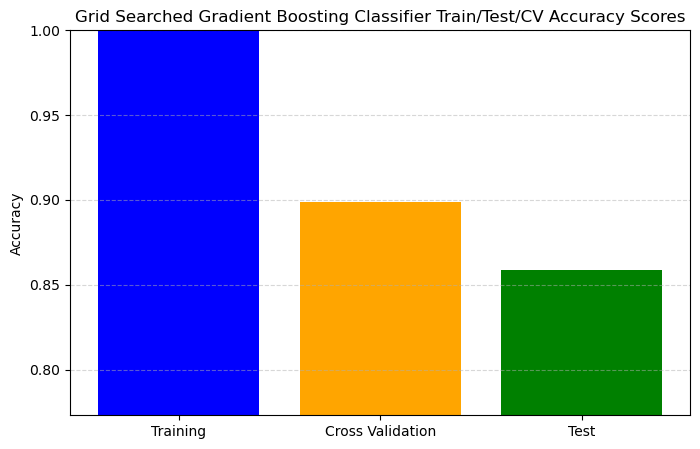

In [ ]:
import matplotlib.pyplot as plt

scores = [
    grid_search_gbc_train_score,
    grid_searched_gbc_cross_val_scores.mean(),
    grid_search_gbc_test_score
]

labels = ['Training', 'Cross Validation', 'Test']

plt.figure(figsize=(8,5))
plt.bar(labels, scores, color=['blue', 'orange', 'green'])
plt.ylim(0.9 * min(scores), 1)# (ChatGPT, 2025)
plt.ylabel("Accuracy")
plt.title("Grid Searched Gradient Boosting Classifier Train/Test/CV Accuracy Scores")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
gbc_top_perf = grid_searched_best_model_gbc #top preforming model after hyperparameter tuning

In [ ]:
with open('gradient_decsion_tree_scores.txt', 'w') as f:
    f.write(f'Best Gradient Boosting Classifier Mean CV Score: {grid_searched_gbc_cross_val_scores.mean()}')
    for i, score in enumerate(grid_searched_gbc_cross_val_scores):
        f.write(f'\nFold {i+1} CV Score: {score}')
    f.close()

## Results and Evaluation

In [ ]:
print('Results Summary for Top Performing Models:')
print('\n')
print('Logistic Regression Classifier:')
print(f"Training Score: {grid_searched_logclf_train_score}")
print(f" Test Score: {grid_searched_logclf_test_score}")
print(f" Mean CV Score: {grid_searched_logclf_cross_val_scores.mean()}")
print('\n')
print('Gradient Boosting Classifier:')
print(f"Training Score: {grid_search_gbc_train_score}")
print(f" Test Score: {grid_search_gbc_test_score}")
print(f" Mean CV Score: {grid_searched_gbc_cross_val_scores.mean()}")
mean_cv_score_difference = grid_searched_logclf_cross_val_scores.mean() - grid_searched_gbc_cross_val_scores.mean()

Results Summary for Top Performing Models:


Logistic Regression Classifier:
Training Score: 0.8828250401284109
 Test Score: 0.8717948717948718
 Mean CV Score: 0.8716283716283717


Gradient Boosting Classifier:
Training Score: 1.0
 Test Score: 0.8589743589743589
 Mean CV Score: 0.8986346986346986


In [ ]:
if mean_cv_score_difference > 0:
    print(f'Logistic Regression outperforms Gradient Boosting Classifier by {mean_cv_score_difference} on cross validation.')
else:
    print(f'Gradient Boosting Classifier outperforms Logistic Regression by {-mean_cv_score_difference} om cross validation.')

Gradient Boosting Classifier outperforms Logistic Regression by 0.02700632700632688 om cross validation.


In [ ]:
print('Overfit/Underfit Analysis for Top Performing Models:')
print("Logistic Regression Overfit/Underfit Analysis:")
overfit_underfit_analysis(grid_searched_logclf_train_score, grid_searched_logclf_cross_val_scores.mean())
print ("\n")
print("Gradient Boosting Classifier Overfit/Underfit Analysis:")
overfit_underfit_analysis(grid_search_gbc_train_score, grid_searched_gbc_cross_val_scores.mean())

Overfit/Underfit Analysis for Top Performing Models:
Logistic Regression Overfit/Underfit Analysis:
Training Score: 0.8828250401284109
Cross Validation Score: 0.8716283716283717
The model is overfitting.
Difference: 0.011196668500039197


Gradient Boosting Classifier Overfit/Underfit Analysis:
Training Score: 1.0
Cross Validation Score: 0.8986346986346986
The model is overfitting.
Difference: 0.10136530136530142


### Training, Validation, and Test Performance comparison

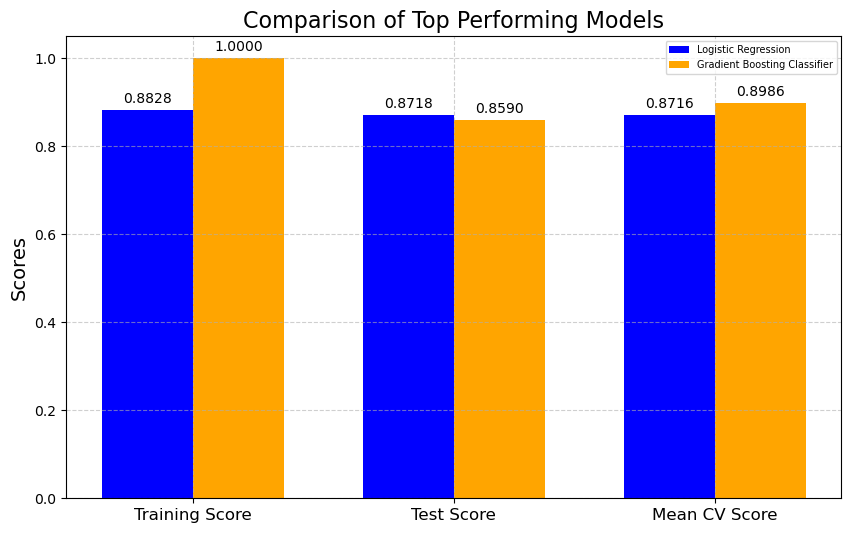

In [ ]:
import numpy as np
labels = ['Training Score', 'Test Score', 'Mean CV Score']
logclf_scores = [grid_searched_logclf_train_score, grid_searched_logclf_test_score, grid_searched_logclf_cross_val_scores.mean()]
gbc_scores = [grid_search_gbc_train_score, grid_search_gbc_test_score, grid_searched_gbc_cross_val_scores.mean()]
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, logclf_scores, width, label='Logistic Regression', color='blue') #ChatGPT, 2025
bars2 = ax.bar(x + width/2, gbc_scores, width, label='Gradient Boosting Classifier', color='orange') #ChatGPT, 2025
ax.set_ylabel('Scores', fontsize=14)
ax.set_title('Comparison of Top Performing Models', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=7)
def autolabel(bars):
    """Attach a text label above each bar in *bars*, displaying its height."""
    for bar in bars: #ChatGPT, 2025
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
autolabel(bars1)
autolabel(bars2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Figure 21: Training, Validation, and Test Accuracy

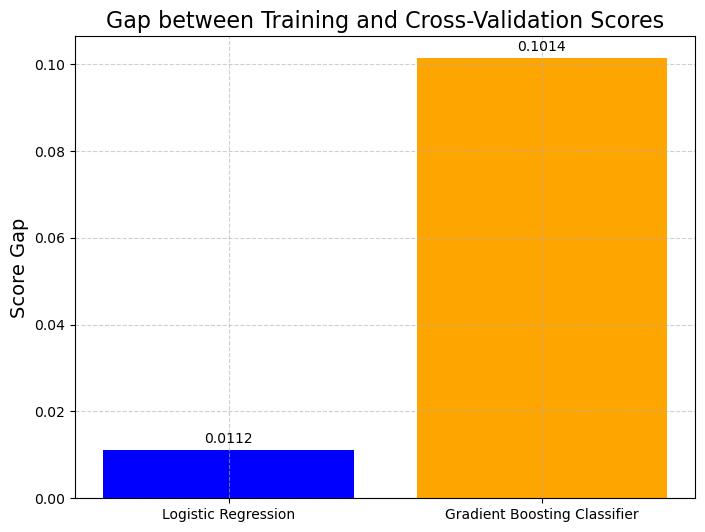

In [ ]:
models = ['Logistic Regression', 'Gradient Boosting Classifier']
gaps = [
    grid_searched_logclf_train_score - grid_searched_logclf_cross_val_scores.mean(),
    grid_search_gbc_train_score - grid_searched_gbc_cross_val_scores.mean()
]
plt.figure(figsize=(8,6))
bars = plt.bar(models, gaps, color=['blue', 'orange'])
plt.title('Gap between Training and Cross-Validation Scores', fontsize=16)
plt.ylabel('Score Gap', fontsize=14)
for bar in bars: #ChatGPT, 2025
    height = bar.get_height()
    plt.annotate(f'{height:.4f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Figure 22: Training–Validation Accuracy Gap for Both Models

### Precision, Recall, and F1-Score comparison

In [ ]:
from sklearn.metrics import precision_score, recall_score
logclf_predictions = logclf_top_perf.predict(X_test)
logclf_precision = precision_score(y_test, logclf_predictions)
logclf_recall = recall_score(y_test, logclf_predictions)
print(f'Logistic Regression Precision: {logclf_precision}')
print(f'Logistic Regression Recall: {logclf_recall}')

Logistic Regression Precision: 0.803030303030303
Logistic Regression Recall: 0.8833333333333333


In [ ]:
gbc_predictions = gbc_top_perf.predict(X_test)
gbc_precision = precision_score(y_test, gbc_predictions)
gbc_recall = recall_score(y_test, gbc_predictions)
print(f'Gradient Boosting Classifier Precision: {gbc_precision}')
print(f'Gradient Boosting Classifier Recall: {gbc_recall}')

Gradient Boosting Classifier Precision: 0.8518518518518519
Gradient Boosting Classifier Recall: 0.7666666666666667


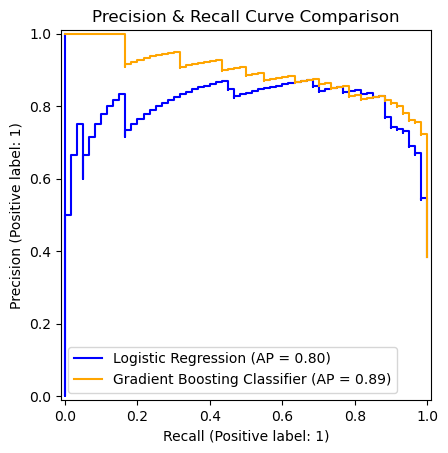

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
logclf_disp = PrecisionRecallDisplay.from_estimator(logclf_top_perf, X_test, y_test, name="Logistic Regression", color='blue')
gbc_disp = PrecisionRecallDisplay.from_estimator(gbc_top_perf, X_test, y_test, name="Gradient Boosting Classifier", color='orange', ax=logclf_disp.ax_)
logclf_disp.ax_.set_title('Precision & Recall Curve Comparison')
plt.show()

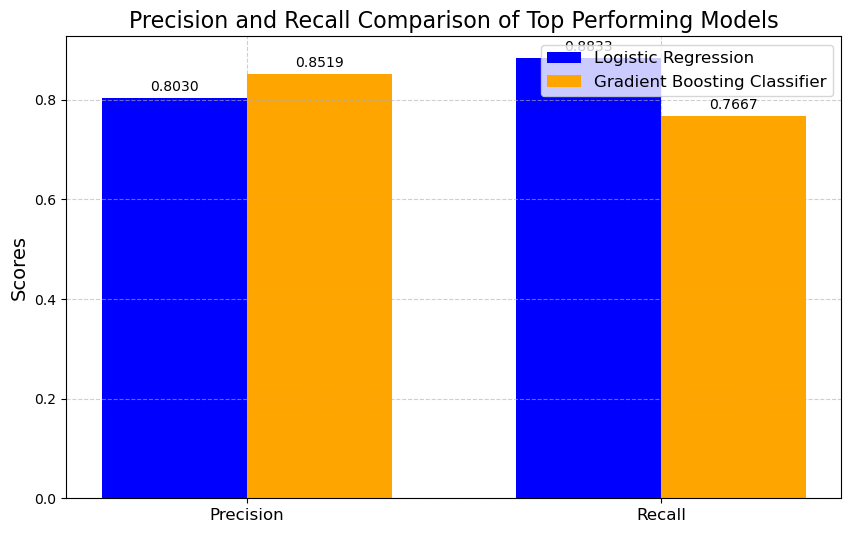

In [ ]:
import numpy as np
labels = ['Precision', 'Recall']
logclf_scores = [logclf_precision, logclf_recall]
gbc_scores = [gbc_precision, gbc_recall]
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, logclf_scores, width, label='Logistic Regression', color='blue') #ChatGPT, 2025
bars2 = ax.bar(x + width/2, gbc_scores, width, label='Gradient Boosting Classifier', color='orange') #ChatGPT, 2025

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores', fontsize=14)
ax.set_title('Precision and Recall Comparison of Top Performing Models', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=12)
# Attach a text label above each bar in *bars*, displaying its height.
def autolabel(bars):
    """Attach a text label above each bar in *bars*, displaying its height."""
    for bar in bars: ##ChatGPT, 2025
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
autolabel(bars1)
autolabel(bars2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Figure 24: Precision and Recall for Both Models

In [ ]:
from sklearn.metrics import f1_score
logclf_f1 = f1_score(y_test, logclf_predictions)
gbc_f1 = f1_score(y_test, gbc_predictions)
print(f'Logistic Regression F1 Score: {logclf_f1}')
print(f'Gradient Boosting Classifier F1 Score: {gbc_f1}')

Logistic Regression F1 Score: 0.8412698412698413
Gradient Boosting Classifier F1 Score: 0.8070175438596491


figure 25: F1 scores for both models

### ROC and AUC performance comparison

/opt/anaconda3/envs/TsunamiRiskModelConda/lib/python3.12/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/anaconda3/envs/TsunamiRiskModelConda/lib/python3.12/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


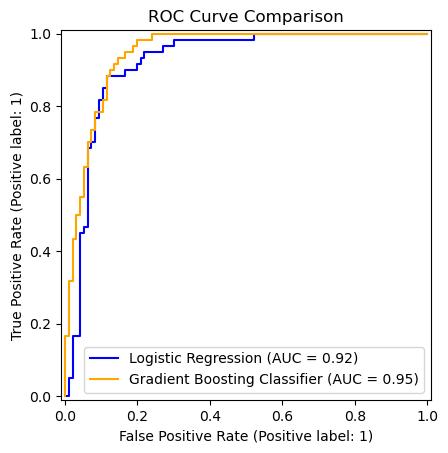

In [ ]:
from sklearn.metrics import RocCurveDisplay
logclf_roc_disp = RocCurveDisplay.from_estimator(logclf_top_perf, X_test, y_test, name="Logistic Regression", color='blue')
gbc_roc_disp = RocCurveDisplay.from_estimator(gbc_top_perf, X_test, y_test, name="Gradient Boosting Classifier", color='orange', ax=logclf_roc_disp.ax_)
logclf_roc_disp.ax_.set_title('ROC Curve Comparison')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
logclf_auc_roc = roc_auc_score(y_test, logclf_predictions)
print(f'Logistic Regression AUC ROC: {logclf_auc_roc}')
gbc_auc_roc = roc_auc_score(y_test, gbc_predictions)
print(f'Gradient Boosting Classifier AUC ROC: {gbc_auc_roc}')

Logistic Regression AUC ROC: 0.8739583333333333
Gradient Boosting Classifier AUC ROC: 0.8416666666666666


figure 27: ROC scores for both models

### Confusion Matrix Analysis

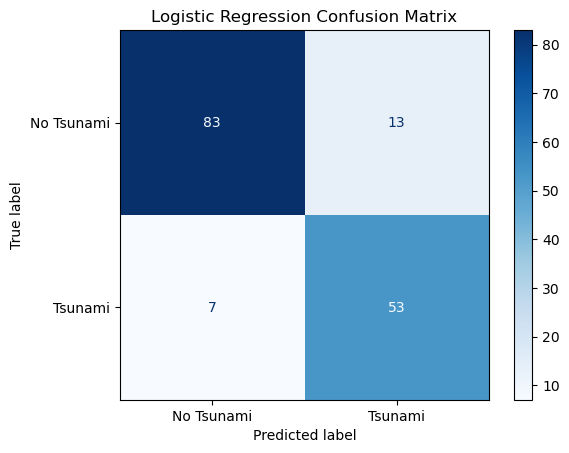

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
logclf_cm_disp = ConfusionMatrixDisplay.from_estimator(logclf_top_perf, X_test, y_test, display_labels=['No Tsunami', 'Tsunami'], cmap='Blues')
logclf_cm_disp.ax_.set_title('Logistic Regression Confusion Matrix')
plt.show()

Figure 28: Logistic Regression Confusion Matrices

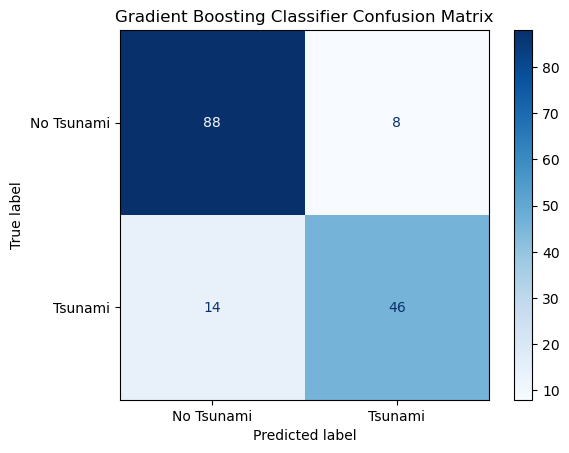

In [ ]:
gbc_cm_disp = ConfusionMatrixDisplay.from_estimator(gbc_top_perf, X_test, y_test, display_labels=['No Tsunami', 'Tsunami'], cmap='Blues')
gbc_cm_disp.ax_.set_title('Gradient Boosting Classifier Confusion Matrix')
plt.show()

figure 29: Confusion Matrices for Gradient Boosting Classifier

### Statistical Significance Testing

In [ ]:
from scipy.stats import ttest_rel
t_stat, p_value = ttest_rel(grid_searched_logclf_cross_val_scores, grid_searched_gbc_cross_val_scores)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
if p_value < 0.05:
    print('The difference in model performance is statistically significant.')
else:
    print('The difference in model performance is not statistically significant.')

T-statistic: -3.1885507043392844, P-value: 0.011032215883589255
The difference in model performance is statistically significant.


Figure 30: T-Test Results Comparing Model CV Accuracies

### Model comparison summary

The results inform us that both models performed well on there training data, before and after hyperparameter tuning, achieving over 85% accuracy. Demostrating that both models understanding the underlying patterns of the data. The higher training score, 100%, of the gradient boosting classifier indicating it has a more developed understanding of the training data compared to logistic regression. It continued to marginally outperform logistic regression on test and validation data (figure 21) indicating its superior generalization capabilities. Yet the large gap between training and validation scores (figure 22) indicates greater overfitting compared to logistic regression.

Both models achieved similar precision, recall, and F1-scores (figures 24 and 25), indicating they are comparably effective at identifying tsunami events. Precsion was slightly higher for the gradient boosting classifier, showing it makes fewer false positive predictions. However, recall was marginally better for logistic regression, indicating it captures more true tsunami events. The higher F1-score of the gradient boosting classifier informs us a better balance between precision and recall overall, something that is vital for effective tsunami prediction to minimize both false alarms and missed events. Although minimally, the higher AUC of the gradient boosting classifier (figure 27) further supports its superior overall performance in distinguishing between tsunami and non-tsunami events across various classification thresholds.

The confusion matrices (figures 28 and 29) reveal that gradient boosting classifier makes fewer misclassifications overall compared to logistic regression, though it had slightly more false negatives, confirming the precision and recall results observed earlier. Our statistical significance testing on cross validation accuracies (figure 30), showed the gradient boosting classifier's accuracy advantage was statistically significant. This acknowledges a real performance difference between the models, this is important given marginal differences between the models accross most performance metrics.

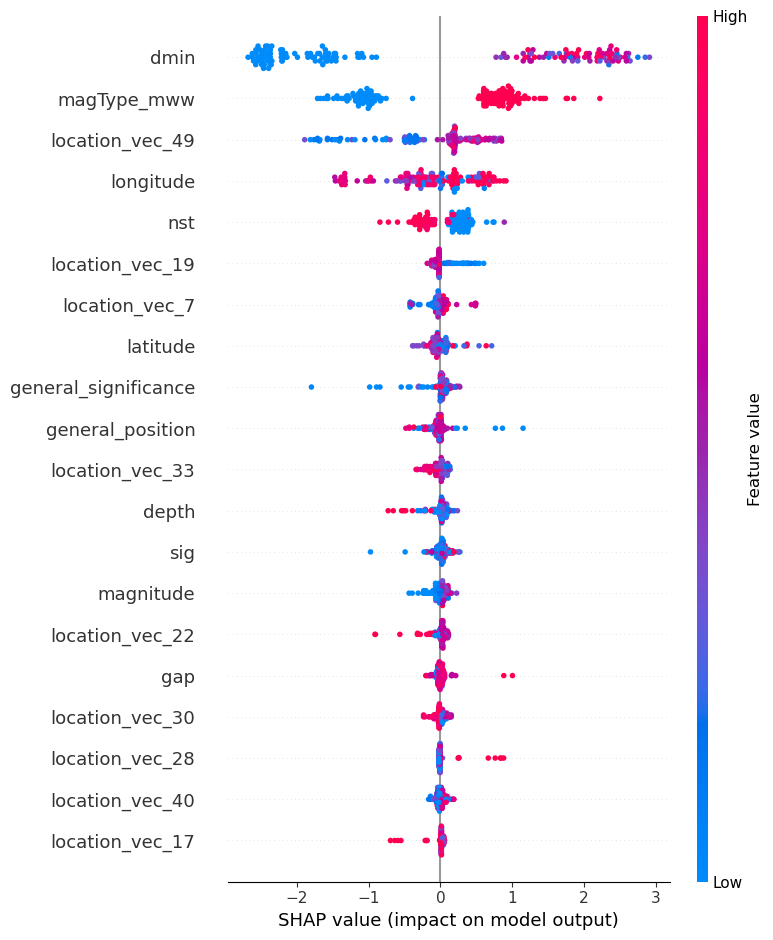

In [ ]:
explainer_gbc = shap.TreeExplainer(gbc_top_perf)
shap_values_gbc = explainer_gbc.shap_values(X_test)
shap.summary_plot(shap_values_gbc, X_test, plot_type='dot')

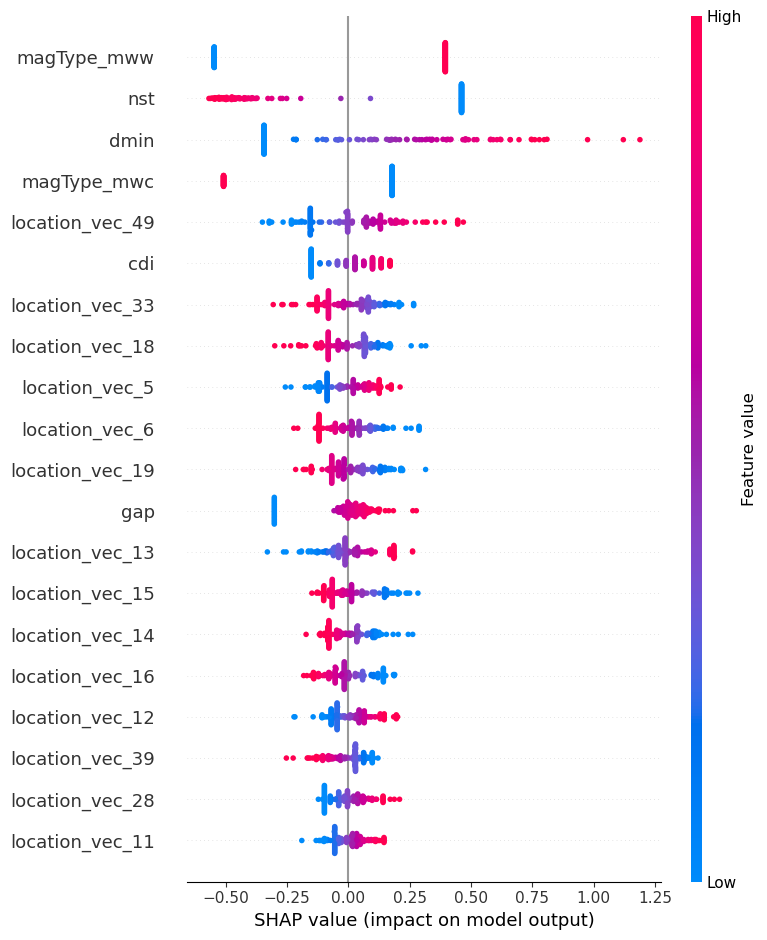

In [ ]:
explainer = shap.Explainer(logclf_top_perf, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values.values, X_test)

#### Research questions

`Will a gradient decsion boosting classifier outperform logistic regression in predicting tsunami occurrence following earthquakes based on seismic event characteristics?`

Based on our analysis, the gradient boosting classifier modestly outperformed logistic regression acrosss a majority of evaluation metrics, including accuracy, precision, F1-score, and ROC AUC scores. Logistic regression achieved a slightly higher recall score, indicating it may be better at identifying actual tsunami events. but the higher F1 score of the gradient boosting classifier suggests it is better overall at balancing false positives and false negatives. These finding are verified in statisical significance testing, which confirmed that the performance difference between the two models is statistically significant in favour of the gradient boosting classifier. Therefore, we conculude that the gradient boosting classifier is the better model for predicting tsunami occurrence following earthquakes based on seismic event characteristics.

`Which feature will be the most important predictor of tsunami occurrence following earthquakes?`

The SHAP summary plots inform us that `dmin` (horizontal distance from the epicenter to the nearest station) is the most important predictor of tsunami occurrence following earthquakes while `nst` (total number of seismic stations used to determine earthquake location) is of highest important to the Logistic Regression model, the Gradient Boosting classifier achieved greater overall performance, so we conclude that `dmin` is the most important predictor overall. Although this may appear unconventional, the literature notes that the majority of seismic stations are located on land, meaning that earthquakes occurring further from land (higher `dmin` values) are more likely to be undersea events capable of generating tsunamis.

(Marra et al., 2017; United States Geological Survey, 2025)


The location text vectors also ranked highly in feature importance for both models, indicating that geographic patterns and seismic hotspots play a significant role in tsunami prediction. However, `dmin` has a more direct relationship with tsunami occurrence, making it the most important predictor overall.

#### Limitations and Future Work

While our models performed well, we encountered limitations. The small size of the dataset may impact our models generalization abilities; expanding the dataset would likely improve model robustness. We also faced class imbalance, with significantly fewer tsunami events compared to non-tsunami events, class weights were applied to the logistic regression model to address this. However, future work could explore SMOTE (Blagus & Lusa, 2013) to generate synthetic samples of the minority class in combination with a larger dataset to mitigate overfitting concerns. Furthermore, we investigated only two types of models. Future research could investigate other machine learning algorithms, such as TabTransformer first invisioned by (Huang et al., 2020).

## Reflection

This project enhanced my understanding of machine learning through practical challenges I encountered. My model comparison revealed through various metrics that the performance tradeoff where logistic regression's simplicity versus gradient boostings complexity showed algorithmic sophistication doesn't guarantee proportional gains.

A significant challenge I faced was addressing extreme outliers through logarithmic transformations, new to my experience. The log1p transformation I applied normalized skewed distributions while preserving zero values, demonstrating preprocessing's impact on model stability. SHAP analysis revealed models prioritized instrumental factors (`dmin`) over traditional seismic characteristics, challenging my initial assumptions and emphasizing data-driven feature importance. Through systematic hyperparameter optimization I reinforced iterative model development, with cross-validation proving essential for robust performance estimation. This experience shifted my approach from algorithm centered implementation toward comprehensive problem solving encompassing data quality, feature engineering, and model interpretability.

In [ ]:
#TODO: GenAI Appendix
#TODO: Reflection and Ethics section

# References:

Chauhan, C. (2025) Earthquake dataset. Kaggle. Available from: https://www.kaggle.com/datasets/warcoder/earthquake-dataset?select=earthquake_data.csv [Accessed 24 October 2025].

United States Geological Survey (USGS) (no date) Earthquake Hazards Program Glossary. U.S. Geological Survey. Available from: https://www.usgs.gov/glossary/earthquake-hazards-program [Accessed 26 October 2025].

CDI Wald, D.J., Quitoriano, V., Worden, C.B., Hopper, M. and Dewey, J.W. (2011) ‘USGS “Did You Feel It?”: Internet-based macroseismic intensity maps’, Annals of Geophysics, 54(6), pp. 688–707. Available from: https://www.researchgate.net/publication/268368064_USGS_Did_You_Feel_It_Internet-based_macroseismic_intensity_maps [Accessed 26 October 2025].

United States Geological Survey (USGS) (1989) Modified Mercalli Intensity Scale. U.S. Geological Survey. Available from: https://www.usgs.gov/programs/earthquake-hazards/modified-mercalli-intensity-scale [Accessed 26 October 2025].

United States Geological Survey (USGS) (2010) PAGER Scientific Background. U.S. Geological Survey. Available from: https://earthquake.usgs.gov/data/pager/background.php [Accessed 26 October 2025].

itdxer (2017) ‘What does average of word2vec vector mean?’, Cross Validated – Statistics Stack Exchange, 14 December. Available from: https://stats.stackexchange.com/questions/318882/what-does-average-of-word2vec-vector-mean[Accessed 3 November 2025].

United States Geological Survey (2022) Why is the earthquake that was reported/recorded by network X, or that I felt, not on the Latest Earthquakes map/list? Available from: https://www.usgs.gov/faqs/why-earthquake-was-reportedrecorded-network-x-or-i-felt-not-latest-earthquakes-maplist [Accessed 3 November 2025]

A l w a y s S u n n y, 2019. pandas convert from datetime to integer timestamp Stack Overflow. Available at: https://stackoverflow.com/questions/54312802/pandas-convert-from-datetime-to-integer-timestamp [Accessed 4 Nov. 2025].

GeeksforGeeks, 2025. Feature Importance with Random Forests Available at: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests [Accessed 4 November 2025].

ChatGPT, 2025. General multi-use session. Available at: https://chatgpt.com/c/6909a310-4050-832b-94b1-35a82b81cec3 [Accessed 7-15th November 2025].

Blagus, R. & Lusa, L., 2013. SMOTE for high-dimensional class-imbalanced data. BMC Bioinformatics, 14, p.106.
Available at: https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-14-106 [Accessed 5 November 2025].

Huang, X., Khetan, A., Cvitkovic, M., & Karnin, Z. (2020). TabTransformer: Tabular Data Modeling Using Contextual Embeddings. Available at: https://doi.org/10.48550/arXiv.2012.06678 (Accessed: 13 November 2025).

Lomax, A., Michelini, A. and Piatanesi, A., 2011. An assessment of rapid magnitude and tsunami potential estimation for shallow earthquakes. Available at: https://academic.oup.com/gji/article/185/1/283/602131 (Accessed: 13 November 2025).

United States Geological Survey (USGS) 2023, Tsunamis and tsunami-hazards, U.S. Geological Survey https://www.usgs.gov/water-science-school/science/tsunamis-and-tsunami-hazards. (Accessed: 13 November 2025).

Google LLC (2025) Class‑imbalanced datasets. Google Developers, viewed 13 November 2025, https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets. (Accessed: 13 November 2025).

Wainwright, M. J., Ravikumar, P. & Lafferty, J. D. (2006) High‑Dimensional Graphical Model Selection Using Regularized Logistic Regression. Neural Information Processing Systems Foundation. Available at: https://proceedings.neurips.cc/paper_files/paper/2006/file/86b20716fbd5b253d27cec43127089bc-Paper.pdf (Accessed: 13 November 2025).

Ayer, T., Chhatwal, J., Alagoz, O., Kahn, C. E. Jr., Woods, R. W. & Burnside, E. S. (2010) ‘Informatics in Radiology: Comparison of Logistic Regression and Artificial Neural Network Models in Breast Cancer Risk Estimation’. Available at: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3709515 (Accessed: 14 November 2025).

Lee, F. (2025) What is logistic regression? IBM. Available at: https://www.ibm.com/think/topics/logistic-regression (Accessed: 13 November 2025).

Friedman, J.H., 1999. Greedy function approximation: A gradient boosting machine. Available at: https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boosting-machine/10.1214/aos/1013203451.full (Accessed: 14 November 2025).

Natekin, A. & Knoll, A., 2013. Gradient boosting machines, a tutorial. Frontiers in Neurorobotics. Available at: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3885826/ [Accessed 13 November 2025].

Luo, J., Yuan, Y. & Xu, S., 2024. Improving GBDT Performance on Imbalanced Datasets: An Empirical Study of Class‑Balanced Loss Functions. Available at: https://doi.org/10.48550/arXiv.2407.14381 (Accessed: 13 November 2025).

Peter, S., Diego, F., Hamprecht, F.A. & Nadler, B., 2017. Cost efficient gradient boosting. Available at: https://papers.nips.cc/paper/6753-cost-efficient-gradient-boosting.pdf (Accessed: 13 November 2025).

Matplotlib (no date) Matplotlib. Available from: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html [Accessed 3 November 2025].

Marra, G. et al. (2017) ‘Seismology with optical links: enabling a global network for submarine earthquake monitoring’. Available at: https://arxiv.org/abs/1801.02698 (Accessed: 26 November 2025).

United States Geological Survey (USGS) (2025) What is it about an earthquake that causes a tsunami? Available at: https://www.usgs.gov/faqs/what-it-about-earthquake-causes-a-tsunami (Accessed: 26 November 2025).


# Appendix

## AI Usage Disclosure

All code generated by AI was carefully checked using my own knowledge of programming from a career in software development as well as cross referncing with online searches and documentation to ensure accuracy and appropriateness for the task at hand.

All AI generated code is marked with a reference to (ChatGPT, 2025)

Queries used:

- "Write a Python snippet using pandas and numpy that applies a log transformation to a subset of columns in a dataframe."

- "make a bit of python using pandas and matplotlib that takes a dataset of features and a separate dataset of feature importances selects a group of features based on a common naming pattern calculates the total importance of that feature group takes the importance of one individual feature  and visualizes the comparison with a bar chart"

- "use matplotlib that adjusts the y-axis limits of a matplotlib plot to zoom in on a specific range so that small differences are more visible" templated code reused 7 times in different places

- Given python matplotlib code X highlight the highest bar in the chart' - templated code reused in 2 times in different places

- "python code using matplotlib that creates a grouped bar chart comparing two sets of numeric values the code should plot the bars side by side with different colors and labels, and annotate each bar with its exact height value on top" templated code reused 3 times in different places


Each of these queries produced code snippets that were then adapted and integrated into the project as appropriate.

Multi use chatgpt session used (ChatGPT, 2025) in order to store keep track of all queries and responses - https://chatgpt.com/c/6909a310-4050-832b-94b1-35a82b81cec3 


